# 📊 Análisis de 3 Estrategias para Productos Estructurados

## Estrategia 1 · Nota Best-Of (AAPL + MSFT + GOOGL) 
## Estrategia 2 · Long Call MSFT / Long Put XOM — Nota con Estrategia Long-Short
## Estrategia 3 · Nota Basket Bull Call Spread —  (JPM · WMT · MSFT)

---

| Campo | Valor |
|---|---|
| Plazo S1, S2 & S3 | 3 meses |
| Inversión | $100,000 USD |
| Tasa libre de riesgo | 3.62% (T-bill 3M)|

**Estrategia 1 - Nota Best-Of**
- **Tesis**: Aprovechar la tendencia alcista en la revalorización de acciones tecnológicas
- **Estructura**: Bull Call Spread para AAPL, MSFT y GOOGL.
- **Capital Protegido**: El bono garantiza 100% del capital.

**Estrategia 2 — Nota Direccional Long-Short**
- **Tesis**: MSFT sube (call gana), XOM baja (put gana).
- **Estructura**: Long Call ATM sobre MSFT + Long Put ATM sobre XOM.
- **Capital protegido**: El bono garantiza 100% del capital.
- **Participación**: 100% fija. Payoff ≥ 0 siempre.

**Estrategia 3 — PPN Bull Call Spread sobre Basket**
- **Tesis**: Basket JPM/WMT/MSFT (mínima varianza) con alza moderada.
- **Estructura**: Long Call ATM + Short Call OTM (cap 15%) sobre basket.
- **Capital protegido**: El bono garantiza 100% del capital.
- **Participación**: 100% fija. Upside acotado al cap del spread.

## 1. Instalación de dependencias

In [65]:
import sys
!{sys.executable} -m pip install seaborn yfinance scipy matplotlib numpy pandas --quiet


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip3.12 install --upgrade pip


## 2. Importación de librerías

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import yfinance as yf
from scipy.optimize import minimize
from scipy.stats import norm
from dataclasses import dataclass
from typing import List, Tuple, Dict
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'DejaVu Sans'
print("✓ Librerías cargadas")

✓ Librerías cargadas


## 3. Infraestructura Black-Scholes

In [67]:
@dataclass
class OptionElement:
    """Opción europea individual (Black-Scholes con dividendos continuos)."""
    type: str
    strike: float
    time_to_expiry: float
    volatility: float = 0.25
    int_rate: float   = 0.05
    div_yield: float  = 0.025

    def __post_init__(self):
        assert self.type in ['call', 'put']
        self.phi = 1 if self.type == 'call' else -1

    def bs_price(self, spot: float, t: float = 0) -> float:
        tau = self.time_to_expiry - t
        if tau <= 0:
            return float(np.maximum(self.phi * (spot - self.strike), 0))
        fwd   = spot * np.exp((self.int_rate - self.div_yield) * tau)
        vol_t = self.volatility * np.sqrt(tau)
        d1    = np.log(fwd / self.strike) / vol_t + 0.5 * vol_t
        d2    = d1 - vol_t
        df    = np.exp(-self.int_rate * tau)
        return self.phi * df * (fwd * norm.cdf(self.phi * d1)
                                - self.strike * norm.cdf(self.phi * d2))

    def delta(self, spot: float) -> float:
        tau = self.time_to_expiry
        fwd   = spot * np.exp((self.int_rate - self.div_yield) * tau)
        vol_t = self.volatility * np.sqrt(tau)
        d1    = np.log(fwd / self.strike) / vol_t + 0.5 * vol_t
        return self.phi * norm.cdf(self.phi * d1)


def price_option(otype: str, strike: float, spot: float,
                 vol: float, r: float, div: float, T: float) -> float:
    """Precio BS de una opción europea."""
    return OptionElement(otype, strike, T, vol, r, div).bs_price(spot)


def simulate_gbm(spot: np.ndarray, vols: np.ndarray, corr: np.ndarray,
                 r: float, T: float, n_sims: int, seed: int = 42) -> np.ndarray:
    """Simulación de Movimiento Browniano Geométrico multivariado."""
    np.random.seed(seed)
    L = np.linalg.cholesky(corr)
    Z = np.random.randn(n_sims, len(spot)) @ L.T
    drift = (r - 0.5 * vols ** 2) * T
    return spot * np.exp(drift + vols * np.sqrt(T) * Z)


def portfolio_perf(w: np.ndarray, mu: pd.Series,
                   cov: pd.DataFrame) -> Tuple[float, float]:
    """Retorno y volatilidad anualizada del portafolio."""
    return float(np.dot(w, mu)), float(np.sqrt(w @ cov.values @ w))


def optimize_minvar(cov: pd.DataFrame, n: int) -> np.ndarray:
    """Portafolio de mínima varianza con restricciones long-only."""
    res = minimize(
        lambda w: w @ cov.values @ w,
        [1 / n] * n, method='SLSQP',
        bounds=[(0, 1)] * n,
        constraints={'type': 'eq', 'fun': lambda w: w.sum() - 1}
    )
    return res.x


def optimize_sharpe(mu: pd.Series, cov: pd.DataFrame,
                    rf: float, n: int) -> np.ndarray:
    """Portafolio de máximo Sharpe con restricciones long-only."""
    def neg_sr(w):
        r, s = portfolio_perf(w, mu, cov)
        return -(r - rf) / s
    return minimize(neg_sr, [1 / n] * n, method='SLSQP',
                    bounds=[(0, 1)] * n,
                    constraints={'type': 'eq', 'fun': lambda w: w.sum() - 1}).x

print("✓ Infraestructura BS lista")

✓ Infraestructura BS lista


## 4. ⚙️ Parámetros Globales

In [68]:
# ── Horizonte y capital ──────────────────────────────────────────────────────
START_DATE = '2025-01-01'
END_DATE   = '2026-04-18'
RISK_FREE  = 0.0362          # Tasa libre de riesgo anualizada (USD)
T          = 3 / 12          # Plazo estándar: 3 meses
NOTIONAL   = 100_000         # Capital del inversor ($USD)
N_SIMS     = 100_000         # Simulaciones Monte Carlo
SEED       = 42

# ── Tickers por estrategia ─────────────────────────────────────────────────
TICKERS_S1 = ['AAPL', 'MSFT', 'GOOGL']
TICKERS_S2 = ['MSFT', 'XOM']
TICKERS_S3 = ['JPM', 'WMT', 'MSFT']

ALL_TICKERS = list(dict.fromkeys(TICKERS_S1 + TICKERS_S2 + TICKERS_S3))

# ── Estrategia 1 — Nota Best-Of ────────────────────────────────────────────
S1_PARTICIPATION = 1.00       # Participación en el mejor activo
S1_CAP           = 0.12       # Cap de rentabilidad (12%)
S1_COUPON        = 0.015      # Cupón digital si cualquier activo supera barrera
S1_BARRIER       = 1.05       # Barrera para cupón digital (+5%)

# ── Escenarios ───────────────────────────────────────────────────────────────
SCENARIO_RANGE = np.array([-0.20, -0.15, -0.10, -0.05,
                             0.00,  0.05,  0.10,  0.15, 0.20])

print("✓ Parámetros listos")
print(f"  Tickers únicos: {ALL_TICKERS}")

✓ Parámetros listos
  Tickers únicos: ['AAPL', 'MSFT', 'GOOGL', 'XOM', 'JPM', 'WMT']


## ⚙️ Parámetros de Opciones — Estrategia 2 

**Se pueden editar para adaptar la estrategia a los nuevos datos de las opciones**

Sustituya los valores `None` por los datos reales de su cadena de opciones.
- **`None`** → el script calcula automáticamente (ATM, precio BS, vol histórica).
- **bid/ask**: del broker o terminal (Bloomberg, IBKR, Refinitv, etc.)
- **IV**: volatilidad implícita de la opción seleccionada.

In [69]:
# ══════════════════════════════════════════════════════════════════════════════
# ══  ESTRATEGIA 2 — DATOS DE OPCIONES DE MERCADO (EDITAR AQUÍ)           ══
# ══════════════════════════════════════════════════════════════════════════════

# ── CALL sobre MSFT (Alcista) ─────────────────────────────────────────────────
S2_MSFT_CALL_STRIKE   = 425     # Strike del call. None = ATM automático
S2_MSFT_CALL_MATURITY = T        # Tiempo a vencimiento en años (default = T = 3m)
S2_MSFT_CALL_BID      = 26.00     # Precio bid de mercado. None = usar BS
S2_MSFT_CALL_ASK      = 26.50     # Precio ask de mercado. None = usar BS
S2_MSFT_CALL_IV       = 0.29     # IV de mercado. None = usar vol histórica
S2_MSFT_DIV_YIELD     = 0.008    # Dividend yield continuo MSFT

# ── PUT sobre XOM (Bajista) ───────────────────────────────────────────────────
S2_XOM_PUT_STRIKE     = 145     # Strike del put. None = ATM automático
S2_XOM_PUT_MATURITY   = T        # Tiempo a vencimiento en años (default = T = 3m)
S2_XOM_PUT_BID        = 7.40     # Precio bid de mercado. None = usar BS
S2_XOM_PUT_ASK        = 7.65     # Precio ask de mercado. None = usar BS
S2_XOM_PUT_IV         = 0.290867     # IV de mercado. None = usar vol histórica
S2_XOM_DIV_YIELD      = 0.035    # Dividend yield continuo XOM

# ── Participación (NO MODIFICAR) ─────────────────────────────────────────────
S2_PARTICIPATION = 1.00          # 100% fijo

print("✓ Parámetros de opciones S2 listos")

✓ Parámetros de opciones S2 listos


## 5. 📥 Descarga de datos históricos

In [70]:
print(f"Descargando {ALL_TICKERS}  {START_DATE} → {END_DATE} ...")

raw = yf.download(ALL_TICKERS, start=START_DATE, end=END_DATE,
                  progress=False, auto_adjust=True)

prices_all = raw['Close'] if isinstance(raw.columns, pd.MultiIndex) else raw
prices_all = prices_all[ALL_TICKERS].dropna()

returns_all = prices_all.pct_change().dropna()
spots       = prices_all.iloc[-1]
vols_all    = returns_all.std() * np.sqrt(252)

print(f"\n✓ {len(returns_all)} días de datos | último: {prices_all.index[-1].date()}")
print("\n📊 Spots y volatilidades anualizadas:")
for t in ALL_TICKERS:
    print(f"  {t:6s}  spot=${spots[t]:>9.2f}  vol={vols_all[t]*100:.1f}%")

Descargando ['AAPL', 'MSFT', 'GOOGL', 'XOM', 'JPM', 'WMT']  2025-01-01 → 2026-04-18 ...

✓ 322 días de datos | último: 2026-04-17

📊 Spots y volatilidades anualizadas:
  AAPL    spot=$   270.23  vol=30.9%
  MSFT    spot=$   422.79  vol=26.6%
  GOOGL   spot=$   341.68  vol=31.3%
  XOM     spot=$   146.44  vol=25.2%
  JPM     spot=$   310.29  vol=25.0%
  WMT     spot=$   127.50  vol=25.4%


## 6. Evolución histórica de precios (base 100)

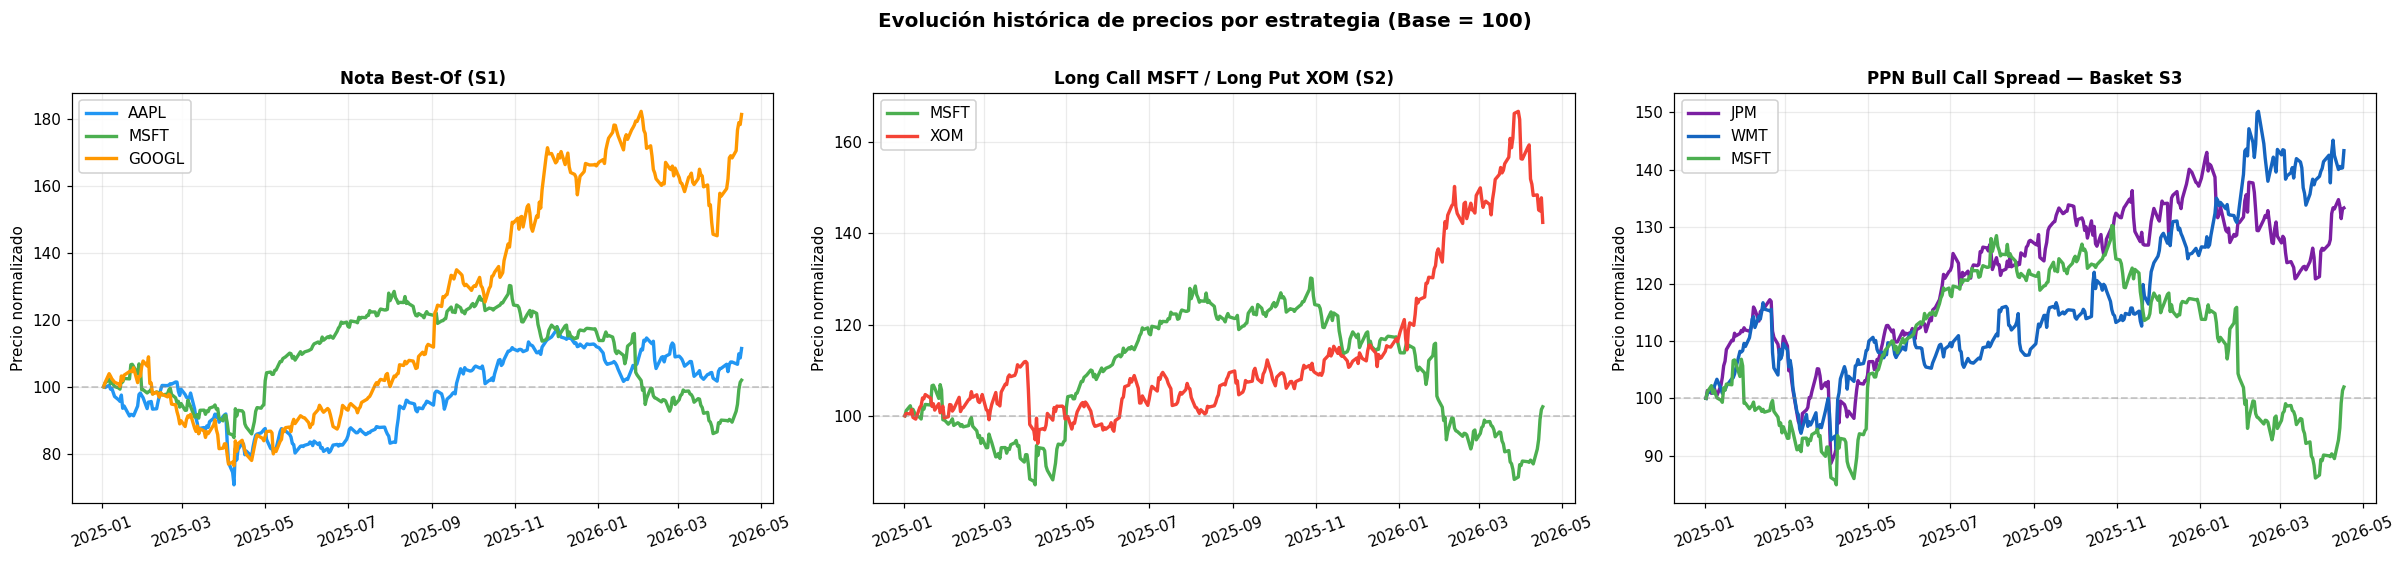


📈 Retornos anualizados:
       Retorno anualizado
Ticker                   
AAPL               +13.2%
MSFT                +5.1%
GOOGL              +51.4%
XOM                +30.9%
JPM                +25.6%
WMT                +31.4%


In [71]:
fig, axes = plt.subplots(1, 3, figsize=(22, 5))

groups = [
    ('Nota Best-Of (S1)',                 TICKERS_S1, ['#2196F3', '#4CAF50', '#FF9800']),
    ('Long Call MSFT / Long Put XOM (S2)', TICKERS_S2, ['#4CAF50', '#F44336']),
    ('PPN Bull Call Spread — Basket S3',  TICKERS_S3, ['#7B1FA2', '#1565C0', '#4CAF50']),
]

for ax, (title, tickers, colors) in zip(axes, groups):
    norm_p = prices_all[tickers] / prices_all[tickers].iloc[0] * 100
    for t, c in zip(tickers, colors):
        ax.plot(norm_p.index, norm_p[t], lw=2.2, color=c, label=t)
    ax.axhline(100, color='gray', ls='--', alpha=0.4, lw=1.2)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_ylabel('Precio normalizado')
    ax.legend(framealpha=0.9)
    ax.grid(True, alpha=0.25)
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Evolución histórica de precios por estrategia (Base = 100)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\n📈 Retornos anualizados:")
ret_anual = returns_all.mean() * 252
print(ret_anual.to_frame('Retorno anualizado').map(lambda x: f'{x*100:+.1f}%'))

---
# 🟦 ESTRATEGIA 1 · Nota Best-Of (AAPL · MSFT · GOOGL)

## S1-A. Portafolio de Mínima Varianza

In [72]:
ret1 = returns_all[TICKERS_S1]
cov1 = ret1.cov() * 252
mu1  = ret1.mean() * 252
n1   = len(TICKERS_S1)

w_sharpe = optimize_sharpe(mu1, cov1, RISK_FREE, n1)
w_minvar = optimize_minvar(cov1, n1)

for w, name in [(w_sharpe, 'MÁXIMO SHARPE'), (w_minvar, 'MÍNIMA VARIANZA ✅')]:
    r, s = portfolio_perf(w, mu1, cov1)
    print(f"\n{'='*50}\n{name}\n{'='*50}")
    for t, wi in zip(TICKERS_S1, w):
        print(f"  {t}: {wi*100:.2f}%")
    print(f"  Retorno: {r*100:.2f}%  |  Vol: {s*100:.2f}%  |  Sharpe: {(r-RISK_FREE)/s:.3f}")

weights_s1 = w_minvar
ret_s1, std_s1 = portfolio_perf(weights_s1, mu1, cov1)
sharpe_s1 = (ret_s1 - RISK_FREE) / std_s1


MÁXIMO SHARPE
  AAPL: 0.00%
  MSFT: 0.00%
  GOOGL: 100.00%
  Retorno: 51.42%  |  Vol: 31.27%  |  Sharpe: 1.528

MÍNIMA VARIANZA ✅
  AAPL: 24.84%
  MSFT: 50.40%
  GOOGL: 24.76%
  Retorno: 18.55%  |  Vol: 22.62%  |  Sharpe: 0.660


## S1-B. Frontera Eficiente

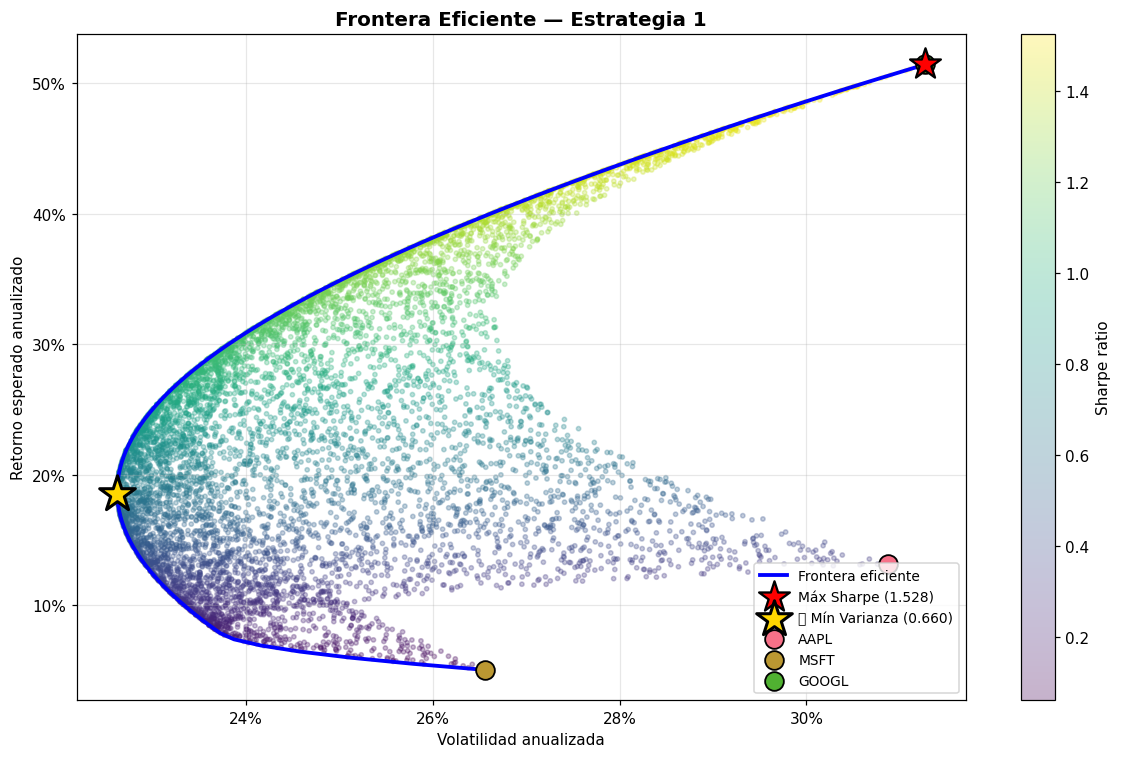

In [73]:
def efficient_frontier(mu, cov, n_pts=100):
    n = len(mu)
    tgts = np.linspace(mu.min(), mu.max(), n_pts)
    vols = []
    for tgt in tgts:
        r = minimize(lambda w: w @ cov.values @ w, [1/n]*n, method='SLSQP',
                     bounds=[(0, 1)]*n,
                     constraints=[
                         {'type': 'eq', 'fun': lambda w: w.sum() - 1},
                         {'type': 'eq', 'fun': lambda w, t=tgt: mu @ w - t}
                     ])
        vols.append(np.sqrt(r.fun) if r.success else np.nan)
    return tgts, np.array(vols)

ef_ret, ef_vol = efficient_frontier(mu1, cov1)

np.random.seed(SEED)
rw = np.random.dirichlet(np.ones(n1), 8000)
rr = rw @ mu1.values
rs = np.sqrt(np.einsum('ij,jk,ik->i', rw, cov1.values, rw))

r_mv, s_mv = portfolio_perf(w_minvar, mu1, cov1)
r_sr, s_sr = portfolio_perf(w_sharpe, mu1, cov1)

fig, ax = plt.subplots(figsize=(11, 7))
sc = ax.scatter(rs, rr, c=(rr - RISK_FREE) / rs, cmap='viridis', alpha=0.3, s=8)
plt.colorbar(sc, label='Sharpe ratio')
ax.plot(ef_vol, ef_ret, 'b-', lw=2.5, label='Frontera eficiente')
ax.scatter(s_sr, r_sr, marker='*', s=450, c='red',  edgecolors='k', lw=1.5, zorder=5,
           label=f"Máx Sharpe ({(r_sr-RISK_FREE)/s_sr:.3f})")
ax.scatter(s_mv, r_mv, marker='*', s=600, c='gold', edgecolors='k', lw=2,   zorder=6,
           label=f"✅ Mín Varianza ({(r_mv-RISK_FREE)/s_mv:.3f})")
for i, t in enumerate(TICKERS_S1):
    ax.scatter(np.sqrt(cov1.iloc[i,i]), mu1.iloc[i], marker='o', s=150,
               edgecolors='k', lw=1.2, label=t, zorder=4)
ax.set_xlabel('Volatilidad anualizada')
ax.set_ylabel('Retorno esperado anualizado')
ax.set_title('Frontera Eficiente — Estrategia 1', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
plt.tight_layout()
plt.show()

## S1-C. Pricing Monte Carlo — Nota Best-Of

In [74]:
spots1 = np.array([spots[t] for t in TICKERS_S1])
vols1  = np.array([vols_all[t] for t in TICKERS_S1])
corr1  = returns_all[TICKERS_S1].corr().values


def note_payoff(finals, spot, notional, part, cap, coupon, barrier):
    """Payoff de la nota Best-Of con cupón digital."""
    ret     = finals / spot - 1
    best    = ret.max(axis=1)
    best_of = np.clip(part * best, 0, cap)
    digital = np.any(finals / spot >= barrier, axis=1).astype(float) * coupon
    return notional * (1 + best_of + digital), best_of, digital


finals1 = simulate_gbm(spots1, vols1, corr1, RISK_FREE, T, N_SIMS, SEED)
payoff1, bo1, dig1 = note_payoff(finals1, spots1, NOTIONAL,
                                  S1_PARTICIPATION, S1_CAP, S1_COUPON, S1_BARRIER)

pv_bond1       = NOTIONAL * np.exp(-RISK_FREE * T)
option_budget1 = NOTIONAL - pv_bond1
fair_value1    = np.exp(-RISK_FREE * T) * payoff1.mean()
exp_ret1       = payoff1.mean() / NOTIONAL - 1

print("=" * 60)
print("  PRICING NOTA BEST-OF (Monte Carlo)")
print("=" * 60)
print(f"  Fair value:                    ${fair_value1:>12,.2f}")
print(f"  Margen banco (nota vendida @par): ${NOTIONAL - fair_value1:>9,.2f}")
print(f"  Retorno esperado (3m):         {exp_ret1*100:>+8.2f}%  →  {exp_ret1/T*100:+.2f}% anual")
print(f"  VP bono (protección capital):  ${pv_bond1:>12,.2f}")
print(f"  Presupuesto opciones:          ${option_budget1:>12,.2f}")
print(f"  Prob. ganancia (> capital):    {(payoff1 > NOTIONAL).mean()*100:>8.1f}%")
print(f"  Prob. alcanzar cap ({S1_CAP*100:.0f}%):    {(bo1 >= S1_CAP-1e-6).mean()*100:>8.1f}%")
print(f"  Prob. cobrar cupón digital:    {(dig1 > 0).mean()*100:>8.1f}%")
print(f"  Payoff promedio:               ${payoff1.mean():>12,.2f}")
print(f"  Payoff percentil 5%:           ${np.percentile(payoff1, 5):>12,.2f}")
print(f"  Payoff percentil 95%:          ${np.percentile(payoff1, 95):>12,.2f}")

  PRICING NOTA BEST-OF (Monte Carlo)
  Fair value:                    $  107,232.58
  Margen banco (nota vendida @par): $-7,232.58
  Retorno esperado (3m):            +8.21%  →  +32.83% anual
  VP bono (protección capital):  $   99,099.08
  Presupuesto opciones:          $      900.92
  Prob. ganancia (> capital):        76.9%
  Prob. alcanzar cap (12%):        43.4%
  Prob. cobrar cupón digital:        63.5%
  Payoff promedio:               $  108,207.44
  Payoff percentil 5%:           $  100,000.00
  Payoff percentil 95%:          $  113,500.00


## S1-D. Diagrama de payoff y distribución

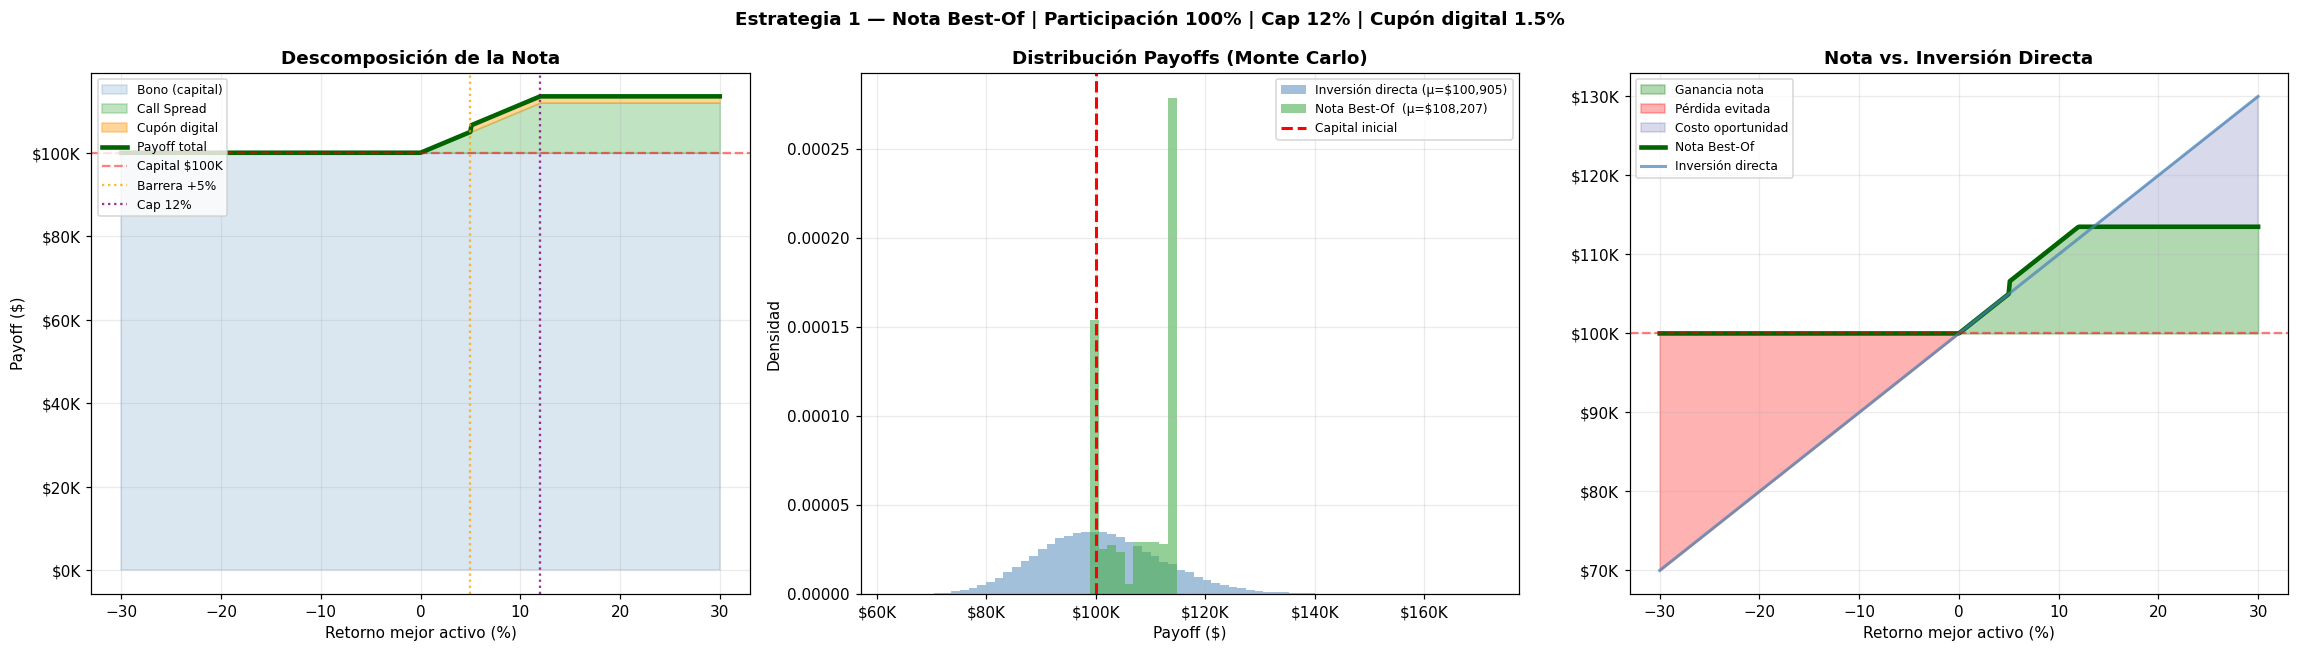

In [75]:
br = np.linspace(-0.30, 0.30, 500)
bond_pf   = np.full_like(br, NOTIONAL)
cs_pf     = np.where(br <= 0, 0, np.minimum(S1_PARTICIPATION * br, S1_CAP) * NOTIONAL)
dig_pf    = np.where(br >= S1_BARRIER - 1, S1_COUPON * NOTIONAL, 0)
total_pf  = bond_pf + cs_pf + dig_pf
direct_pf = NOTIONAL * (1 + br)

ret_sim1   = finals1 / spots1 - 1
direct_mc1 = NOTIONAL * (1 + ret_sim1 @ weights_s1)

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# Panel 1: Descomposición
ax = axes[0]
ax.fill_between(br*100, 0, bond_pf, alpha=0.20, color='steelblue', label='Bono (capital)')
ax.fill_between(br*100, bond_pf, bond_pf+cs_pf, alpha=0.35, color='#4CAF50', label='Call Spread')
ax.fill_between(br*100, bond_pf+cs_pf, total_pf, alpha=0.40, color='#FF9800', label='Cupón digital')
ax.plot(br*100, total_pf, lw=3, color='darkgreen', label='Payoff total')
ax.axhline(NOTIONAL, color='red', ls='--', alpha=0.5, lw=1.5, label=f'Capital ${NOTIONAL/1000:.0f}K')
ax.axvline((S1_BARRIER-1)*100, color='orange', ls=':', alpha=0.8,
           label=f'Barrera +{(S1_BARRIER-1)*100:.0f}%')
ax.axvline(S1_CAP*100, color='purple', ls=':', alpha=0.8, label=f'Cap {S1_CAP*100:.0f}%')
ax.set_title('Descomposición de la Nota', fontweight='bold')
ax.set_xlabel('Retorno mejor activo (%)')
ax.set_ylabel('Payoff ($)')
ax.legend(fontsize=8, loc='upper left')
ax.grid(True, alpha=0.25)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# Panel 2: Distribución MC
ax = axes[1]
lo, hi = min(direct_mc1.min(), payoff1.min()), max(direct_mc1.max(), payoff1.max())
bins = np.linspace(lo, hi, 70)
ax.hist(direct_mc1, bins=bins, alpha=0.50, color='steelblue', density=True,
        label=f'Inversión directa (μ=${direct_mc1.mean():,.0f})')
ax.hist(payoff1,    bins=bins, alpha=0.60, color='#4CAF50',  density=True,
        label=f'Nota Best-Of  (μ=${payoff1.mean():,.0f})')
ax.axvline(NOTIONAL, color='red', ls='--', lw=2, label='Capital inicial')
ax.set_title('Distribución Payoffs (Monte Carlo)', fontweight='bold')
ax.set_xlabel('Payoff ($)')
ax.set_ylabel('Densidad')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# Panel 3: Nota vs. Directa
ax = axes[2]
ax.fill_between(br*100, NOTIONAL, total_pf,
                where=total_pf > NOTIONAL, alpha=0.30, color='green', label='Ganancia nota')
ax.fill_between(br*100, NOTIONAL, direct_pf,
                where=direct_pf < NOTIONAL, alpha=0.30, color='red', label='Pérdida evitada')
ax.fill_between(br*100, total_pf, direct_pf,
                where=direct_pf > total_pf, alpha=0.15, color='navy', label='Costo oportunidad')
ax.plot(br*100, total_pf, lw=3, color='darkgreen', label='Nota Best-Of')
ax.plot(br*100, direct_pf, lw=2, color='steelblue', alpha=0.7, label='Inversión directa')
ax.axhline(NOTIONAL, color='red', ls='--', alpha=0.5)
ax.set_title('Nota vs. Inversión Directa', fontweight='bold')
ax.set_xlabel('Retorno mejor activo (%)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

plt.suptitle(
    f'Estrategia 1 — Nota Best-Of | Participación {S1_PARTICIPATION*100:.0f}% '
    f'| Cap {S1_CAP*100:.0f}% | Cupón digital {S1_COUPON*100:.1f}%',
    fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## S1-E. Tabla de escenarios

In [76]:
rows = []
for r in SCENARIO_RANGE:
    f = spots1 * (1 + r)
    po, bo, dg = note_payoff(f.reshape(1, -1), spots1, NOTIONAL,
                              S1_PARTICIPATION, S1_CAP, S1_COUPON, S1_BARRIER)
    rows.append({'Escenario': f'Todos {r*100:+.0f}%',
                 'AAPL': f'{r*100:+.1f}%', 'MSFT': f'{r*100:+.1f}%', 'GOOGL': f'{r*100:+.1f}%',
                 'Best-Of': f'{bo[0]*100:.2f}%', 'Cupón': f'{dg[0]*100:.2f}%',
                 'Payoff': f'${po[0]:,.0f}', 'Rend.': f'{(po[0]/NOTIONAL-1)*100:+.2f}%'})

for r1, r2, r3, desc in [
    (0.15, 0.20, 0.10, "MSFT líder"),
    (0.08, 0.15, 0.20, "GOOGL lidera"),
    (-0.05, 0.15, -0.05, "Solo MSFT sube"),
    (-0.10, 0.15, -0.05, "MSFT salva trimestre"),
    (-0.15, -0.10, -0.12, "Corrección general"),
]:
    f = np.array([spots1[0]*(1+r1), spots1[1]*(1+r2), spots1[2]*(1+r3)])
    po, bo, dg = note_payoff(f.reshape(1, -1), spots1, NOTIONAL,
                              S1_PARTICIPATION, S1_CAP, S1_COUPON, S1_BARRIER)
    rows.append({'Escenario': desc,
                 'AAPL': f'{r1*100:+.1f}%', 'MSFT': f'{r2*100:+.1f}%', 'GOOGL': f'{r3*100:+.1f}%',
                 'Best-Of': f'{bo[0]*100:.2f}%', 'Cupón': f'{dg[0]*100:.2f}%',
                 'Payoff': f'${po[0]:,.0f}', 'Rend.': f'{(po[0]/NOTIONAL-1)*100:+.2f}%'})

df_s1 = pd.DataFrame(rows)
print(df_s1.to_string(index=False))
df_s1

           Escenario   AAPL   MSFT  GOOGL Best-Of Cupón   Payoff   Rend.
          Todos -20% -20.0% -20.0% -20.0%   0.00% 0.00% $100,000  +0.00%
          Todos -15% -15.0% -15.0% -15.0%   0.00% 0.00% $100,000  +0.00%
          Todos -10% -10.0% -10.0% -10.0%   0.00% 0.00% $100,000  +0.00%
           Todos -5%  -5.0%  -5.0%  -5.0%   0.00% 0.00% $100,000  +0.00%
           Todos +0%  +0.0%  +0.0%  +0.0%   0.00% 0.00% $100,000  +0.00%
           Todos +5%  +5.0%  +5.0%  +5.0%   5.00% 1.50% $106,500  +6.50%
          Todos +10% +10.0% +10.0% +10.0%  10.00% 1.50% $111,500 +11.50%
          Todos +15% +15.0% +15.0% +15.0%  12.00% 1.50% $113,500 +13.50%
          Todos +20% +20.0% +20.0% +20.0%  12.00% 1.50% $113,500 +13.50%
          MSFT líder +15.0% +20.0% +10.0%  12.00% 1.50% $113,500 +13.50%
        GOOGL lidera  +8.0% +15.0% +20.0%  12.00% 1.50% $113,500 +13.50%
      Solo MSFT sube  -5.0% +15.0%  -5.0%  12.00% 1.50% $113,500 +13.50%
MSFT salva trimestre -10.0% +15.0%  -5.0%  12.00% 1

,Escenario,AAPL,MSFT,GOOGL,Best-Of,Cupón,Payoff,Rend.
0,Todos -20%,-20.0%,-20.0%,-20.0%,0.00%,0.00%,"$100,000",+0.00%
1,Todos -15%,-15.0%,-15.0%,-15.0%,0.00%,0.00%,"$100,000",+0.00%
2,Todos -10%,-10.0%,-10.0%,-10.0%,0.00%,0.00%,"$100,000",+0.00%
3,Todos -5%,-5.0%,-5.0%,-5.0%,0.00%,0.00%,"$100,000",+0.00%
4,Todos +0%,+0.0%,+0.0%,+0.0%,0.00%,0.00%,"$100,000",+0.00%
5,Todos +5%,+5.0%,+5.0%,+5.0%,5.00%,1.50%,"$106,500",+6.50%
6,Todos +10%,+10.0%,+10.0%,+10.0%,10.00%,1.50%,"$111,500",+11.50%
7,Todos +15%,+15.0%,+15.0%,+15.0%,12.00%,1.50%,"$113,500",+13.50%
8,Todos +20%,+20.0%,+20.0%,+20.0%,12.00%,1.50%,"$113,500",+13.50%
9,MSFT líder,+15.0%,+20.0%,+10.0%,12.00%,1.50%,"$113,500",+13.50%


---
# 🟩 ESTRATEGIA 2 · Nota Direccional Long-Short (MSFT ↑ / XOM ↓)

## Concepto y estructura

| Pata | Instrumento | Función |
|------|-------------|---------|
| **Pata 1** | Long Call ATM sobre MSFT | Captura upside si MSFT sube |
| **Pata 2** | Long Put ATM sobre XOM  | Captura downside si XOM baja |

**Fórmula del payoff:**
```
Payoff Total = Notional + Notional × 100% × max(0,
                 [max(ST_MSFT - K_MSFT, 0) / S0_MSFT]
               + [max(K_XOM  - ST_XOM,  0) / S0_XOM] )
```
Ambas patas son long options → valor intrínseco ≥ 0 → **Payoff Total ≥ $100,000 siempre.**

## S2-A. Resolución de parámetros (mercado vs. BS)

In [77]:
S0_XOM  = float(spots['XOM'])
S0_XOM

146.44000244140625

In [78]:
# ── Spots iniciales ──────────────────────────────────────────────────────────
S0_MSFT = float(spots['MSFT'])
S0_XOM  = float(spots['XOM'])

VOL_MSFT = float(vols_all['MSFT'])
VOL_XOM  = float(vols_all['XOM'])

# ── Resolver strikes (ATM si no se especifica) ────────────────────────────────
K_MSFT = S2_MSFT_CALL_STRIKE if S2_MSFT_CALL_STRIKE is not None else round(S0_MSFT, 2)
K_XOM  = S2_XOM_PUT_STRIKE   if S2_XOM_PUT_STRIKE   is not None else round(S0_XOM, 2)

# ── Resolver volatilidades implícitas ─────────────────────────────────────────
IV_MSFT = S2_MSFT_CALL_IV if S2_MSFT_CALL_IV is not None else VOL_MSFT
IV_XOM  = S2_XOM_PUT_IV   if S2_XOM_PUT_IV   is not None else VOL_XOM

# ── Maturities ────────────────────────────────────────────────────────────────
T_MSFT = S2_MSFT_CALL_MATURITY
T_XOM  = S2_XOM_PUT_MATURITY

# ── Precios Black-Scholes teóricos ────────────────────────────────────────────
bs_price_call_msft = price_option('call', K_MSFT, S0_MSFT, IV_MSFT,
                                   RISK_FREE, S2_MSFT_DIV_YIELD, T_MSFT)
bs_price_put_xom   = price_option('put',  K_XOM,  S0_XOM,  IV_XOM,
                                   RISK_FREE, S2_XOM_DIV_YIELD,  T_XOM)

# ── Precios de compra: mercado (ask) o BS ─────────────────────────────────────
if S2_MSFT_CALL_BID is not None and S2_MSFT_CALL_ASK is not None:
    market_mid_call   = (S2_MSFT_CALL_BID + S2_MSFT_CALL_ASK) / 2
    cost_call_msft    = S2_MSFT_CALL_ASK
    using_market_msft = True
else:
    market_mid_call   = bs_price_call_msft
    cost_call_msft    = bs_price_call_msft
    using_market_msft = False

if S2_XOM_PUT_BID is not None and S2_XOM_PUT_ASK is not None:
    market_mid_put   = (S2_XOM_PUT_BID + S2_XOM_PUT_ASK) / 2
    cost_put_xom     = S2_XOM_PUT_ASK
    using_market_xom = True
else:
    market_mid_put   = bs_price_put_xom
    cost_put_xom     = bs_price_put_xom
    using_market_xom = False

# ── ZCB y presupuesto ─────────────────────────────────────────────────────────
pv_zcb2           = NOTIONAL * np.exp(-RISK_FREE * T)
option_budget2    = NOTIONAL - pv_zcb2
total_option_cost = cost_call_msft + cost_put_xom

print("=" * 70)
print("  ESTRATEGIA 2 — NOTA DIRECCIONAL LONG-SHORT")
print("  Long Call MSFT / Long Put XOM · Capital 100% Protegido")
print("=" * 70)
print(f"\n  MSFT (Alcista — Long Call)")
print(f"    Spot (S0):         ${S0_MSFT:>10.2f}")
print(f"    Strike (K):        ${K_MSFT:>10.2f}  ({'ATM' if abs(K_MSFT/S0_MSFT - 1) < 0.01 else f'{(K_MSFT/S0_MSFT-1)*100:+.1f}% OTM'})")
print(f"    Madurez:           {T_MSFT*12:>10.1f} meses")
print(f"    IV:                {IV_MSFT*100:>10.1f}%  ({'mercado' if S2_MSFT_CALL_IV is not None else 'histórica'})")
if using_market_msft:
    print(f"    Bid / Ask:         ${S2_MSFT_CALL_BID:>8.2f} / ${S2_MSFT_CALL_ASK:>8.2f}")
print(f"    Precio BS teórico: ${bs_price_call_msft:>10.2f}")
print(f"    Costo de compra:   ${cost_call_msft:>10.2f}  ({'ask mercado' if using_market_msft else 'BS teórico'})")
print(f"\n  XOM (Bajista — Long Put)")
print(f"    Spot (S0):         ${S0_XOM:>10.2f}")
print(f"    Strike (K):        ${K_XOM:>10.2f}  ({'ATM' if abs(K_XOM/S0_XOM - 1) < 0.01 else f'{(K_XOM/S0_XOM-1)*100:+.1f}% OTM'})")
print(f"    Madurez:           {T_XOM*12:>10.1f} meses")
print(f"    IV:                {IV_XOM*100:>10.1f}%  ({'mercado' if S2_XOM_PUT_IV is not None else 'histórica'})")
if using_market_xom:
    print(f"    Bid / Ask:         ${S2_XOM_PUT_BID:>8.2f} / ${S2_XOM_PUT_ASK:>8.2f}")
print(f"    Precio BS teórico: ${bs_price_put_xom:>10.2f}")
print(f"    Costo de compra:   ${cost_put_xom:>10.2f}  ({'ask mercado' if using_market_xom else 'BS teórico'})")
print(f"\n  ESTRUCTURA DE CAPITAL")
print(f"    Notional:              ${NOTIONAL:>12,.2f}")
print(f"    VP del ZCB @ {RISK_FREE*100:.2f}%:    ${pv_zcb2:>12,.2f}")
print(f"    Presupuesto opciones:  ${option_budget2:>12,.2f}")
print(f"    Costo total opciones:  ${total_option_cost:>12,.2f}")
print(f"    Participación:         {'100%':>12}  (fija)")
viable = total_option_cost <= option_budget2
print(f"\n  Factibilidad: {'✅ SÍ — costo cabe en presupuesto' if viable else '⚠️ NO — costo excede presupuesto, ajustar strikes OTM'}")

  ESTRATEGIA 2 — NOTA DIRECCIONAL LONG-SHORT
  Long Call MSFT / Long Put XOM · Capital 100% Protegido

  MSFT (Alcista — Long Call)
    Spot (S0):         $    422.79
    Strike (K):        $    425.00  (ATM)
    Madurez:                  3.0 meses
    IV:                      29.0%  (mercado)
    Bid / Ask:         $   26.00 / $   26.50
    Precio BS teórico: $     24.75
    Costo de compra:   $     26.50  (ask mercado)

  XOM (Bajista — Long Put)
    Spot (S0):         $    146.44
    Strike (K):        $    145.00  (ATM)
    Madurez:                  3.0 meses
    IV:                      29.1%  (mercado)
    Bid / Ask:         $    7.40 / $    7.65
    Precio BS teórico: $      7.66
    Costo de compra:   $      7.65  (ask mercado)

  ESTRUCTURA DE CAPITAL
    Notional:              $  100,000.00
    VP del ZCB @ 3.62%:    $   99,099.08
    Presupuesto opciones:  $      900.92
    Costo total opciones:  $       34.15
    Participación:                 100%  (fija)

  Factibilidad: 

## S2-B. Función de payoff — Derivativo direccional

In [79]:
def directional_ls_payoff(ST_MSFT, ST_XOM, S0_MSFT, S0_XOM,
                          K_MSFT, K_XOM, notional, participation=1.0):
    """
    Payoff de la nota direccional Long Call MSFT + Long Put XOM.

    Payoff Total = notional + notional * participation * max(0,
                       max(ST_MSFT - K_MSFT, 0) / S0_MSFT
                     + max(K_XOM  - ST_XOM,  0) / S0_XOM)

    Como ambas patas son max(..., 0), la suma es siempre >= 0.
    El payoff total para el inversor es siempre >= notional.
    """
    call_intrinsic = np.maximum(ST_MSFT - K_MSFT, 0) / S0_MSFT
    put_intrinsic  = np.maximum(K_XOM   - ST_XOM, 0) / S0_XOM
    raw_return     = call_intrinsic + put_intrinsic
    deriv_return   = participation * np.maximum(raw_return, 0)
    deriv_payoff   = notional * deriv_return
    payoff_total   = notional + deriv_payoff
    return payoff_total, call_intrinsic, put_intrinsic, deriv_payoff

print("✓ Función directional_ls_payoff definida")
print(f"  Payoff = ${NOTIONAL:,} + ${NOTIONAL:,} × 100% × max(0,")
print(f"             [max(ST_MSFT − {K_MSFT:.2f}, 0) / {S0_MSFT:.2f}]")
print(f"           + [max({K_XOM:.2f} − ST_XOM,  0) / {S0_XOM:.2f}] )")

✓ Función directional_ls_payoff definida
  Payoff = $100,000 + $100,000 × 100% × max(0,
             [max(ST_MSFT − 425.00, 0) / 422.79]
           + [max(145.00 − ST_XOM,  0) / 146.44] )


## S2-C. Monte Carlo — Pricing de la nota direccional

In [80]:
spots2 = np.array([S0_MSFT, S0_XOM])
vols2  = np.array([IV_MSFT, IV_XOM])
corr2  = returns_all[TICKERS_S2].corr().values

finals2     = simulate_gbm(spots2, vols2, corr2, RISK_FREE, T, N_SIMS, SEED)
ST_MSFT_sim = finals2[:, 0]
ST_XOM_sim  = finals2[:, 1]

payoff2, call_iv_sim, put_iv_sim, deriv_pf2 = directional_ls_payoff(
    ST_MSFT_sim, ST_XOM_sim,
    S0_MSFT, S0_XOM,
    K_MSFT, K_XOM,
    NOTIONAL, S2_PARTICIPATION
)

fair_value2 = np.exp(-RISK_FREE * T) * payoff2.mean()
exp_ret2    = payoff2.mean() / NOTIONAL - 1

print("=" * 70)
print("  PRICING NOTA DIRECCIONAL LONG-SHORT (Monte Carlo)")
print("=" * 70)
print(f"\n  ✅ GARANTÍA VERIFICADA: payoff mínimo = ${payoff2.min():,.2f}")
print(f"\n  Fair value (VP payoffs):    ${fair_value2:>12,.2f}")
print(f"  Margen banco (@par):        ${NOTIONAL - fair_value2:>12,.2f}")
print(f"  Retorno esperado (3m):      {exp_ret2*100:>+8.2f}%  →  {exp_ret2/T*100:+.2f}% anual")
print(f"  Payoff promedio:            ${payoff2.mean():>12,.2f}")
print(f"  Payoff mínimo:              ${payoff2.min():>12,.2f}")
print(f"  Payoff percentil  5%:       ${np.percentile(payoff2,  5):>12,.2f}")
print(f"  Payoff percentil 50%:       ${np.percentile(payoff2, 50):>12,.2f}")
print(f"  Payoff percentil 95%:       ${np.percentile(payoff2, 95):>12,.2f}")
print(f"  Payoff máximo:              ${payoff2.max():>12,.2f}")
print(f"\n  Prob. ganancia (> capital): {(payoff2 > NOTIONAL).mean()*100:>8.1f}%")
print(f"  Contribución Call MSFT:     {call_iv_sim.mean()*100:>+8.2f}% del S0")
print(f"  Contribución Put  XOM:      {put_iv_sim.mean()*100:>+8.2f}% del S0")

  PRICING NOTA DIRECCIONAL LONG-SHORT (Monte Carlo)

  ✅ GARANTÍA VERIFICADA: payoff mínimo = $100,000.00

  Fair value (VP payoffs):    $  109,984.73
  Margen banco (@par):        $   -9,984.73
  Retorno esperado (3m):        +10.98%  →  +43.94% anual
  Payoff promedio:            $  110,984.61
  Payoff mínimo:              $  100,000.00
  Payoff percentil  5%:       $  100,000.00
  Payoff percentil 50%:       $  107,880.60
  Payoff percentil 95%:       $  134,192.29
  Payoff máximo:              $  202,688.65

  Prob. ganancia (> capital):     73.5%
  Contribución Call MSFT:        +6.07% del S0
  Contribución Put  XOM:         +4.91% del S0


## S2-D. Visualización — Nota Direccional Long-Short

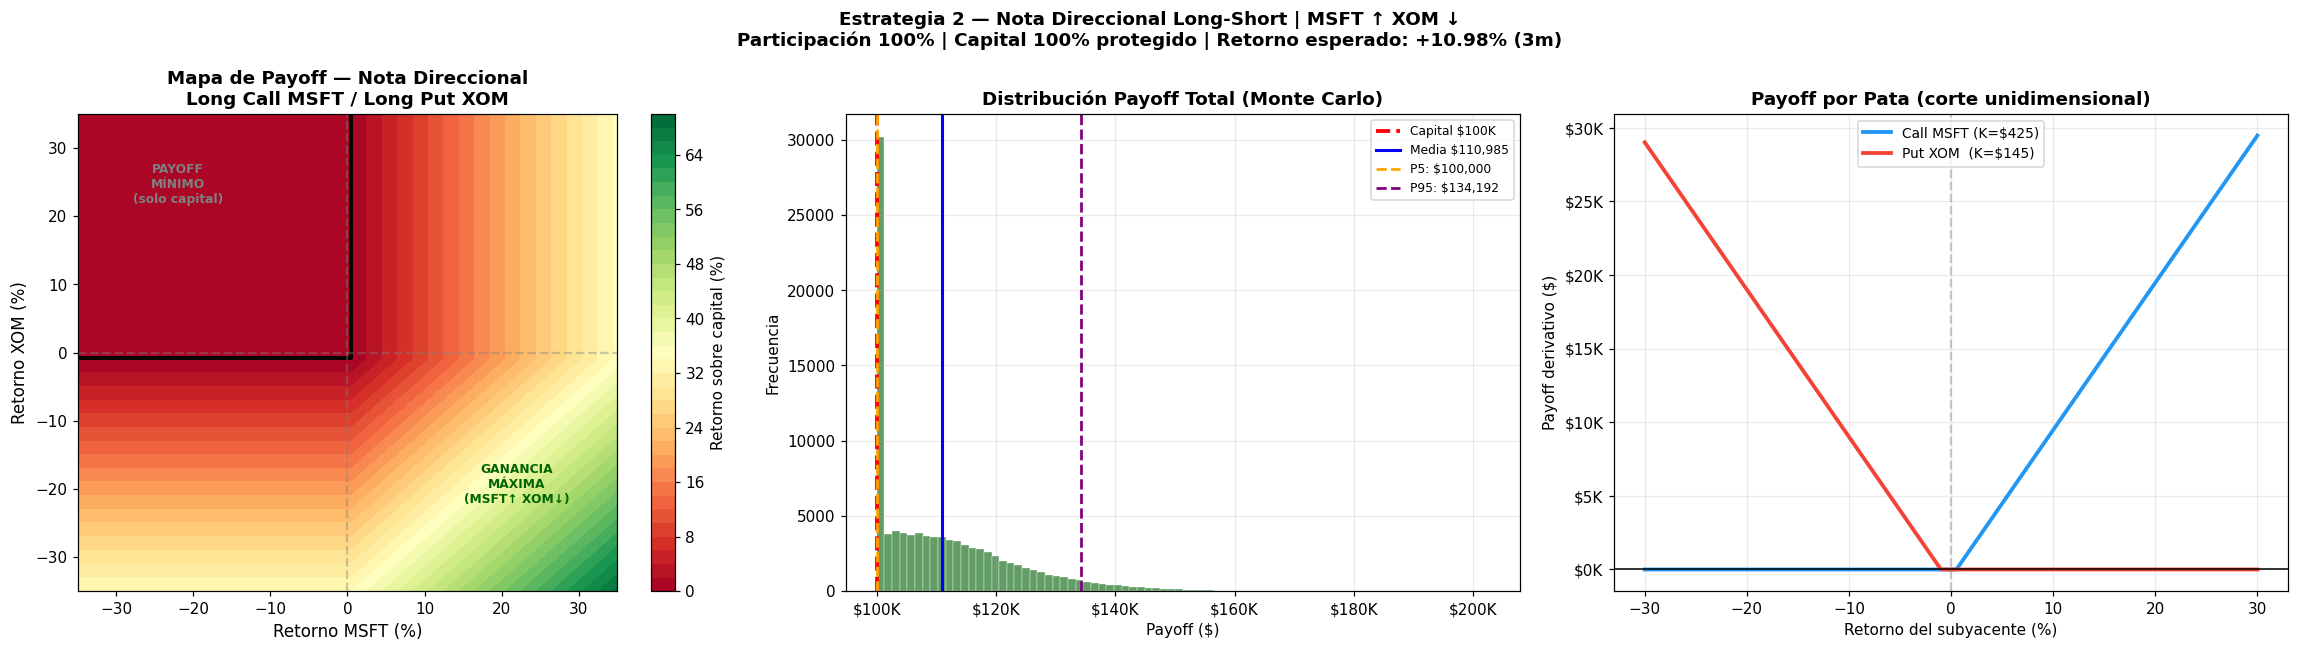

In [81]:
msft_rets = np.linspace(-0.35, 0.35, 220)
xom_rets  = np.linspace(-0.35, 0.35, 220)
M2, X2    = np.meshgrid(msft_rets, xom_rets)

ST_M_grid = S0_MSFT * (1 + M2)
ST_X_grid = S0_XOM  * (1 + X2)

payoff_grid, _, _, deriv_grid = directional_ls_payoff(
    ST_M_grid, ST_X_grid, S0_MSFT, S0_XOM, K_MSFT, K_XOM, NOTIONAL, S2_PARTICIPATION
)
ret_grid = deriv_grid / NOTIONAL * 100

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# Panel 1: Mapa de calor del payoff
ax = axes[0]
im = ax.contourf(M2*100, X2*100, ret_grid, levels=35, cmap='RdYlGn')
ax.contour(M2*100, X2*100, ret_grid, levels=[0], colors='black', linewidths=2.5)
plt.colorbar(im, ax=ax, label='Retorno sobre capital (%)')
ax.set_xlabel('Retorno MSFT (%)', fontsize=11)
ax.set_ylabel('Retorno XOM (%)', fontsize=11)
ax.set_title('Mapa de Payoff — Nota Direccional\nLong Call MSFT / Long Put XOM', fontweight='bold')
ax.axhline(0, color='gray', ls='--', alpha=0.4)
ax.axvline(0, color='gray', ls='--', alpha=0.4)
ax.text(22, -22, 'GANANCIA\nMÁXIMA\n(MSFT↑ XOM↓)', color='darkgreen',
        fontweight='bold', ha='center', fontsize=8)
ax.text(-22, 22, 'PAYOFF\nMÍNIMO\n(solo capital)', color='gray',
        fontweight='bold', ha='center', fontsize=8)

# Panel 2: Distribución Monte Carlo
ax = axes[1]
ax.hist(payoff2, bins=80, color='#2E7D32', alpha=0.75, edgecolor='white', linewidth=0.3)
ax.axvline(NOTIONAL,              color='red',    ls='--', lw=2.5, label=f'Capital ${NOTIONAL/1000:.0f}K')
ax.axvline(payoff2.mean(),        color='blue',   ls='-',  lw=2,   label=f'Media ${payoff2.mean():,.0f}')
ax.axvline(np.percentile(payoff2,  5), color='orange', ls='--', lw=1.8, label=f'P5: ${np.percentile(payoff2,5):,.0f}')
ax.axvline(np.percentile(payoff2, 95), color='purple', ls='--', lw=1.8, label=f'P95: ${np.percentile(payoff2,95):,.0f}')
ax.set_title('Distribución Payoff Total (Monte Carlo)', fontweight='bold')
ax.set_xlabel('Payoff ($)')
ax.set_ylabel('Frecuencia')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# Panel 3: Payoff por pata (corte unidimensional)
ax = axes[2]
rng_1d   = np.linspace(-0.30, 0.30, 500)
call_1d  = np.maximum(S0_MSFT*(1+rng_1d) - K_MSFT, 0) / S0_MSFT * NOTIONAL
put_1d   = np.maximum(K_XOM - S0_XOM*(1+rng_1d), 0) / S0_XOM * NOTIONAL
ax.plot(rng_1d*100,  call_1d, lw=2.5, color='#2196F3', label=f'Call MSFT (K=${K_MSFT:.0f})')
ax.plot(rng_1d*100,  put_1d,  lw=2.5, color='#F44336', label=f'Put XOM  (K=${K_XOM:.0f})')
ax.axhline(0, color='black', lw=1)
ax.axvline(0, color='gray', ls='--', alpha=0.4)
ax.set_title('Payoff por Pata (corte unidimensional)', fontweight='bold')
ax.set_xlabel('Retorno del subyacente (%)')
ax.set_ylabel('Payoff derivativo ($)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

plt.suptitle(
    f'Estrategia 2 — Nota Direccional Long-Short | MSFT ↑ XOM ↓\n'
    f'Participación 100% | Capital 100% protegido | '
    f'Retorno esperado: {exp_ret2*100:+.2f}% (3m)',
    fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## S2-E. Tabla de escenarios numéricos

In [82]:
print("\n" + "=" * 90)
print("  ANÁLISIS DE ESCENARIOS — NOTA DIRECCIONAL LONG-SHORT")
print("=" * 90)

scenarios_s2 = [
    ( 0.20, -0.20, "Escenario 1: MSFT +20% / XOM -20%  ← MEJOR CASO"),
    ( 0.15, -0.15, "Escenario 1b: MSFT +15% / XOM -15%"),
    ( 0.05, -0.05, "Escenario 2: MSFT +5% / XOM -5% (leve)"),
    ( 0.10,  0.00, "MSFT +10% / XOM flat"),
    ( 0.00, -0.10, "MSFT flat / XOM -10%"),
    ( 0.10,  0.10, "Ambos +10% (mercado sube)"),
    (-0.10, -0.10, "Ambos -10% (mercado baja)"),
    (-0.05,  0.05, "Escenario 3: MSFT -5% / XOM +5%  ← PEOR TESIS"),
    (-0.15,  0.15, "MSFT -15% / XOM +15%  ← peor escenario"),
    ( 0.00,  0.00, "Sin movimiento (flat)"),
    ( 0.25, -0.25, "Rally extremo pro-tesis"),
]

rows_s2 = []
for ret_m, ret_x, desc in scenarios_s2:
    st_m = S0_MSFT * (1 + ret_m)
    st_x = S0_XOM  * (1 + ret_x)
    call_iv   = max(st_m - K_MSFT, 0)
    put_iv    = max(K_XOM - st_x, 0)
    call_norm = call_iv / S0_MSFT
    put_norm  = put_iv  / S0_XOM
    deriv_ret = S2_PARTICIPATION * max(call_norm + put_norm, 0)
    deriv_usd = NOTIONAL * deriv_ret
    total_pay = NOTIONAL + deriv_usd
    rows_s2.append({
        'Escenario':     desc,
        'MSFT ret':      f'{ret_m*100:+.0f}%',
        'XOM ret':       f'{ret_x*100:+.0f}%',
        'ST_MSFT':       f'${st_m:,.2f}',
        'ST_XOM':        f'${st_x:,.2f}',
        'Call IV (MSFT)':f'${call_iv:,.2f}',
        'Put IV (XOM)':  f'${put_iv:,.2f}',
        'Deriv %':       f'{deriv_ret*100:+.2f}%',
        'Payoff':        f'${total_pay:,.0f}',
        'Rend. 3m':      f'{(total_pay/NOTIONAL-1)*100:+.2f}%',
        'Resultado':     '✅ Ganancia' if total_pay > NOTIONAL else '⬜ Solo capital',
    })

df_s2 = pd.DataFrame(rows_s2)
print(df_s2.to_string(index=False))
df_s2


  ANÁLISIS DE ESCENARIOS — NOTA DIRECCIONAL LONG-SHORT
                                      Escenario MSFT ret XOM ret ST_MSFT  ST_XOM Call IV (MSFT) Put IV (XOM) Deriv %   Payoff Rend. 3m      Resultado
Escenario 1: MSFT +20% / XOM -20%  ← MEJOR CASO     +20%    -20% $507.35 $117.15         $82.35       $27.85 +38.49% $138,494  +38.49%     ✅ Ganancia
             Escenario 1b: MSFT +15% / XOM -15%     +15%    -15% $486.21 $124.47         $61.21       $20.53 +28.49% $128,494  +28.49%     ✅ Ganancia
         Escenario 2: MSFT +5% / XOM -5% (leve)      +5%     -5% $443.93 $139.12         $18.93        $5.88  +8.49% $108,494   +8.49%     ✅ Ganancia
                           MSFT +10% / XOM flat     +10%     +0% $465.07 $146.44         $40.07        $0.00  +9.48% $109,477   +9.48%     ✅ Ganancia
                           MSFT flat / XOM -10%      +0%    -10% $422.79 $131.80          $0.00       $13.20  +9.02% $109,017   +9.02%     ✅ Ganancia
                      Ambos +10% (mercado su

,Escenario,MSFT ret,XOM ret,ST_MSFT,ST_XOM,Call IV (MSFT),Put IV (XOM),Deriv %,Payoff,Rend. 3m,Resultado
0,Escenario 1: MSFT +20% / XOM -20% ← MEJOR CASO,+20%,-20%,$507.35,$117.15,$82.35,$27.85,+38.49%,"$138,494",+38.49%,✅ Ganancia
1,Escenario 1b: MSFT +15% / XOM -15%,+15%,-15%,$486.21,$124.47,$61.21,$20.53,+28.49%,"$128,494",+28.49%,✅ Ganancia
2,Escenario 2: MSFT +5% / XOM -5% (leve),+5%,-5%,$443.93,$139.12,$18.93,$5.88,+8.49%,"$108,494",+8.49%,✅ Ganancia
3,MSFT +10% / XOM flat,+10%,+0%,$465.07,$146.44,$40.07,$0.00,+9.48%,"$109,477",+9.48%,✅ Ganancia
4,MSFT flat / XOM -10%,+0%,-10%,$422.79,$131.80,$0.00,$13.20,+9.02%,"$109,017",+9.02%,✅ Ganancia
5,Ambos +10% (mercado sube),+10%,+10%,$465.07,$161.08,$40.07,$0.00,+9.48%,"$109,477",+9.48%,✅ Ganancia
6,Ambos -10% (mercado baja),-10%,-10%,$380.51,$131.80,$0.00,$13.20,+9.02%,"$109,017",+9.02%,✅ Ganancia
7,Escenario 3: MSFT -5% / XOM +5% ← PEOR TESIS,-5%,+5%,$401.65,$153.76,$0.00,$0.00,+0.00%,"$100,000",+0.00%,⬜ Solo capital
8,MSFT -15% / XOM +15% ← peor escenario,-15%,+15%,$359.37,$168.41,$0.00,$0.00,+0.00%,"$100,000",+0.00%,⬜ Solo capital
9,Sin movimiento (flat),+0%,+0%,$422.79,$146.44,$0.00,$0.00,+0.00%,"$100,000",+0.00%,⬜ Solo capital


## S2-F. Análisis de primas y factibilidad de estructuración

In [83]:
print("\n" + "=" * 70)
print("  ANÁLISIS DE PRIMAS Y FACTIBILIDAD DE ESTRUCTURACIÓN")
print("=" * 70)

print(f"\n  Long Call MSFT (K=${K_MSFT:.2f}):")
print(f"    Precio BS teórico:   ${bs_price_call_msft:>10.2f}")
print(f"    Costo de compra:     ${cost_call_msft:>10.2f}  ({'ask de mercado' if using_market_msft else 'BS teórico'})")
if using_market_msft:
    spread_call = S2_MSFT_CALL_ASK - S2_MSFT_CALL_BID
    print(f"    Spread bid/ask:      ${spread_call:>10.2f}  ({spread_call/market_mid_call*100:.1f}% del mid)")

print(f"\n  Long Put XOM (K=${K_XOM:.2f}):")
print(f"    Precio BS teórico:   ${bs_price_put_xom:>10.2f}")
print(f"    Costo de compra:     ${cost_put_xom:>10.2f}  ({'ask de mercado' if using_market_xom else 'BS teórico'})")
if using_market_xom:
    spread_put = S2_XOM_PUT_ASK - S2_XOM_PUT_BID
    print(f"    Spread bid/ask:      ${spread_put:>10.2f}  ({spread_put/market_mid_put*100:.1f}% del mid)")

print(f"\n  TOTALES:")
print(f"    Costo opciones:        ${total_option_cost:>10.2f}")
print(f"    Presupuesto (N - ZCB): ${option_budget2:>10.2f}")
print(f"    Margen / Excedente:    ${option_budget2 - total_option_cost:>+10.2f}")
viable = total_option_cost <= option_budget2
print(f"\n  {'✅ VIABLE: primas dentro del presupuesto' if viable else '⚠️ NO VIABLE: ajustar strikes OTM o ampliar plazo'}")

print(f"""
  Notas sobre primas y trade-offs:
  • Spreads bid/ask estrechos → mayor liquidez (opciones ATM, vencimientos estándar).
  • Strikes OTM → primas más baratas, mayor movimiento requerido para ganar.
  • Strikes ITM → primas más caras, valor intrínseco inicial, mayor prob. de ganancia.
  • Mayor plazo T → primas más caras, más convexidad, pero ZCB rinde más.
  • Correlación negativa MSFT/XOM beneficia la estructura: ambas patas ganan juntas.""")

corr_msft_xom = returns_all[['MSFT', 'XOM']].corr().loc['MSFT', 'XOM']
print(f"\n  Correlación histórica MSFT / XOM: {corr_msft_xom:.3f}")
print(f"  {'→ Correlación baja/negativa — estructura favorecida ✅' if corr_msft_xom < 0.3 else '→ Correlación moderada/alta — diversificación limitada'}")


  ANÁLISIS DE PRIMAS Y FACTIBILIDAD DE ESTRUCTURACIÓN

  Long Call MSFT (K=$425.00):
    Precio BS teórico:   $     24.75
    Costo de compra:     $     26.50  (ask de mercado)
    Spread bid/ask:      $      0.50  (1.9% del mid)

  Long Put XOM (K=$145.00):
    Precio BS teórico:   $      7.66
    Costo de compra:     $      7.65  (ask de mercado)
    Spread bid/ask:      $      0.25  (3.3% del mid)

  TOTALES:
    Costo opciones:        $     34.15
    Presupuesto (N - ZCB): $    900.92
    Margen / Excedente:    $   +866.77

  ✅ VIABLE: primas dentro del presupuesto

  Notas sobre primas y trade-offs:
  • Spreads bid/ask estrechos → mayor liquidez (opciones ATM, vencimientos estándar).
  • Strikes OTM → primas más baratas, mayor movimiento requerido para ganar.
  • Strikes ITM → primas más caras, valor intrínseco inicial, mayor prob. de ganancia.
  • Mayor plazo T → primas más caras, más convexidad, pero ZCB rinde más.
  • Correlación negativa MSFT/XOM beneficia la estructura: amba

## S2-G. Distribución del payoff total del inversor

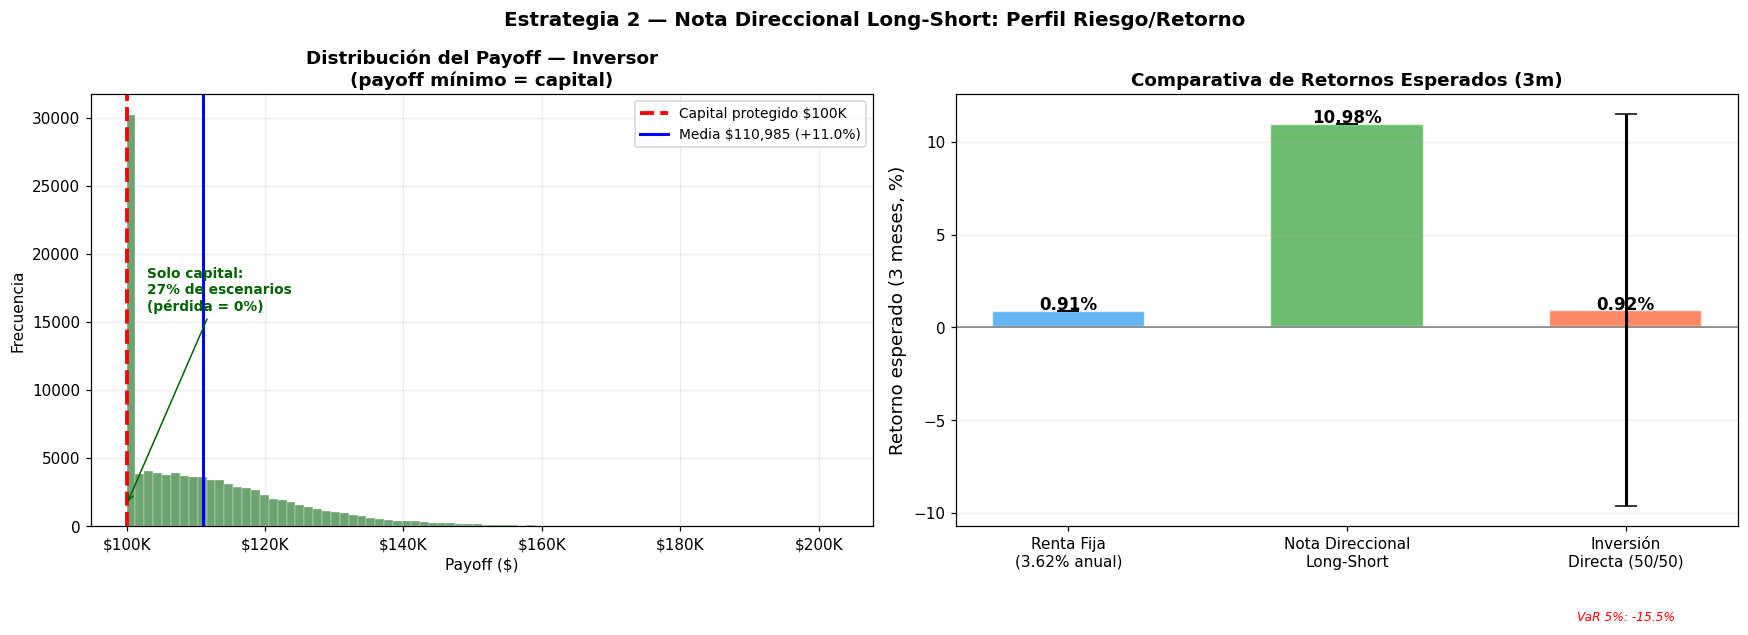

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Histograma del payoff
ax = axes[0]
ax.hist(payoff2, bins=80, color='#2E7D32', alpha=0.7, edgecolor='white', linewidth=0.3)
ax.axvline(NOTIONAL,       color='red',  ls='--', lw=2.5, label=f'Capital protegido ${NOTIONAL/1000:.0f}K')
ax.axvline(payoff2.mean(), color='blue', ls='-',  lw=2,
           label=f'Media ${payoff2.mean():,.0f} ({exp_ret2*100:+.1f}%)')
only_capital_pct = (payoff2 <= NOTIONAL + 1).mean() * 100
ax.annotate(f'Solo capital:\n{only_capital_pct:.0f}% de escenarios\n(pérdida = 0%)',
            xy=(NOTIONAL, ax.get_ylim()[1]*0.05 if ax.get_ylim()[1] > 0 else 1000),
            xytext=(NOTIONAL * 1.03, ax.get_ylim()[1]*0.5 if ax.get_ylim()[1] > 0 else 5000),
            fontsize=9, color='darkgreen', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='darkgreen'))
ax.set_title('Distribución del Payoff — Inversor\n(payoff mínimo = capital)', fontweight='bold')
ax.set_xlabel('Payoff ($)')
ax.set_ylabel('Frecuencia')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# Panel 2: Comparativa retornos esperados
ax2 = axes[1]
rf_return    = RISK_FREE * T * 100
note_return  = exp_ret2 * 100
direct_sim   = 0.5 * (finals2[:, 0]/S0_MSFT - 1) + 0.5 * (finals2[:, 1]/S0_XOM - 1)
direct_mean  = float(direct_sim.mean()) * 100
direct_std   = float(direct_sim.std()) * 100
direct_worst = float(np.percentile(direct_sim, 5)) * 100

strat_labels = ['Renta Fija\n(3.62% anual)', 'Nota Direccional\nLong-Short', 'Inversión\nDirecta (50/50)']
bar_vals     = [rf_return, note_return, direct_mean]
bcolors      = ['#42A5F5', '#4CAF50', '#FF7043']

bars2 = ax2.bar(strat_labels, bar_vals, color=bcolors, alpha=0.82,
                edgecolor='white', linewidth=1.5, width=0.55)
ax2.errorbar(strat_labels, bar_vals, yerr=[0, 0, direct_std],
             fmt='none', color='black', capsize=7, linewidth=2)
for bar, val in zip(bars2, bar_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, max(val, 0) + 0.05,
             f'{val:.2f}%', ha='center', fontweight='bold', fontsize=11)
ax2.text(2, direct_worst - 0.35, f'VaR 5%: {direct_worst:.1f}%',
         ha='center', fontsize=8, color='red', style='italic')
ax2.axhline(0, color='black', lw=1, alpha=0.5)
ax2.set_ylabel('Retorno esperado (3 meses, %)', fontsize=12)
ax2.set_title('Comparativa de Retornos Esperados (3m)', fontweight='bold')
ax2.grid(True, alpha=0.25, axis='y')

plt.suptitle('Estrategia 2 — Nota Direccional Long-Short: Perfil Riesgo/Retorno',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## S2-H. Descomposición de la nota y perfil de ganancia

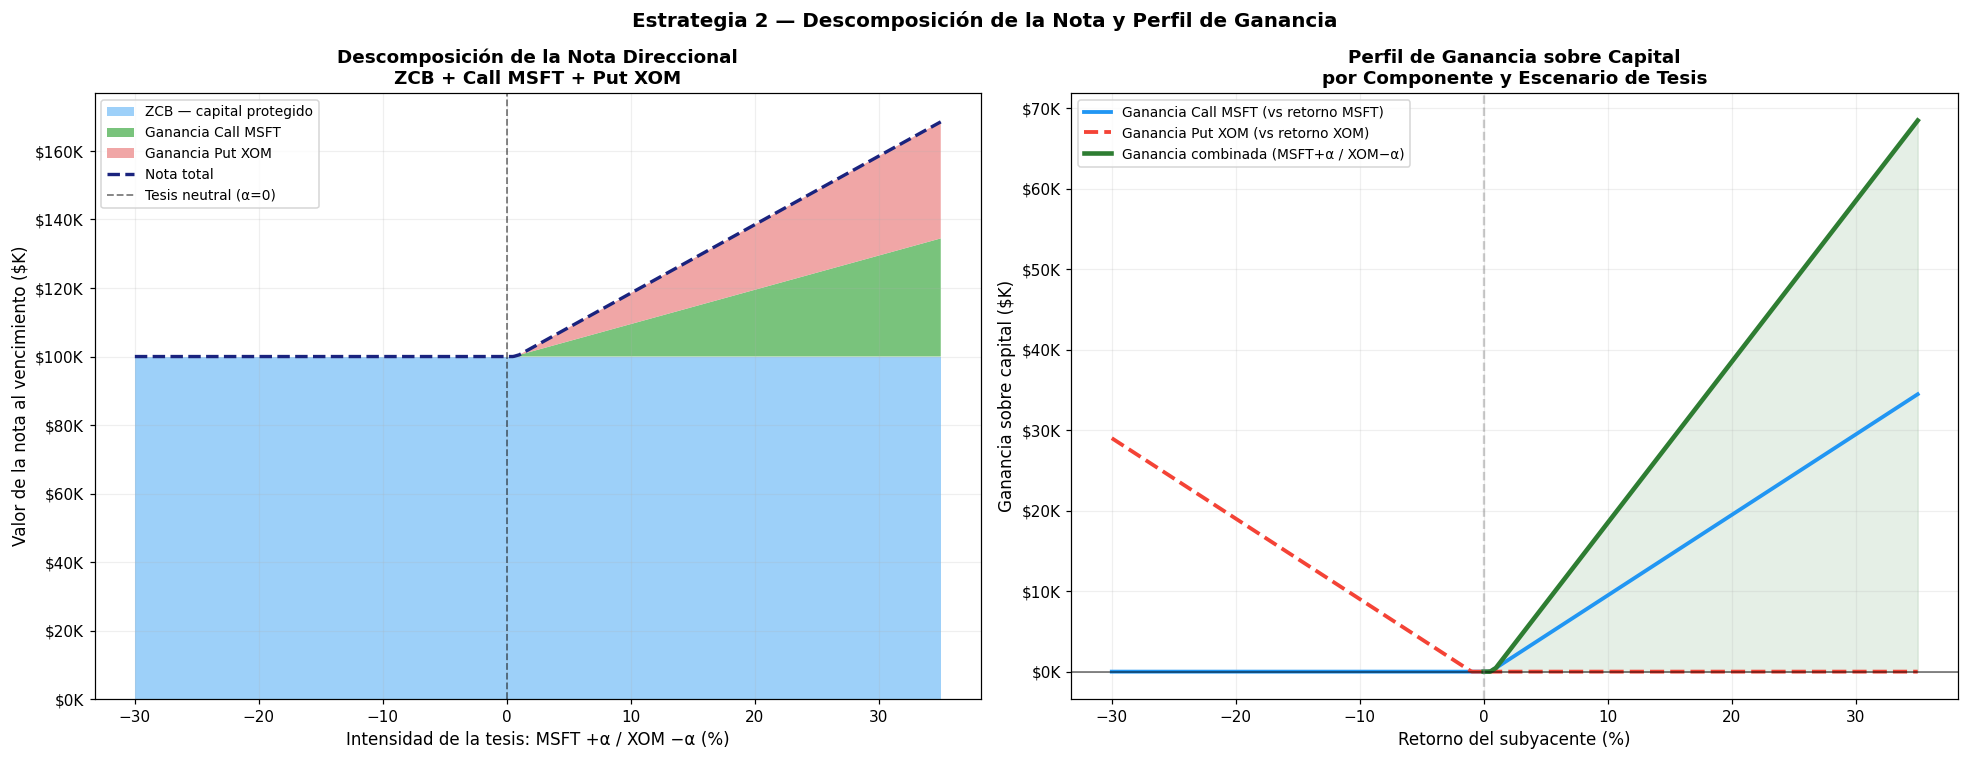

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Panel 1: Descomposición de componentes (escenario tesis: MSFT+α / XOM-α) ──
ax = axes[0]
alpha = np.linspace(-0.30, 0.35, 500)
ST_M_a = S0_MSFT * (1 + alpha)
ST_X_a = S0_XOM  * (1 - alpha)

zcb_comp  = np.full(len(alpha), NOTIONAL)
call_comp = np.maximum(ST_M_a - K_MSFT, 0) / S0_MSFT * NOTIONAL * S2_PARTICIPATION
put_comp  = np.maximum(K_XOM  - ST_X_a, 0) / S0_XOM  * NOTIONAL * S2_PARTICIPATION

ax.stackplot(
    alpha * 100,
    zcb_comp  / 1000,
    call_comp / 1000,
    put_comp  / 1000,
    labels=['ZCB — capital protegido', 'Ganancia Call MSFT', 'Ganancia Put XOM'],
    colors=['#90CAF9', '#66BB6A', '#EF9A9A'],
    alpha=0.88
)
total_comp = (zcb_comp + call_comp + put_comp) / 1000
ax.plot(alpha * 100, total_comp, lw=2.2, color='#1A237E', ls='--', label='Nota total')
ax.axvline(0, color='black', ls='--', lw=1.2, alpha=0.5, label='Tesis neutral (α=0)')
ax.set_xlabel('Intensidad de la tesis: MSFT +α / XOM −α (%)', fontsize=11)
ax.set_ylabel('Valor de la nota al vencimiento ($K)', fontsize=11)
ax.set_title('Descomposición de la Nota Direccional\nZCB + Call MSFT + Put XOM', fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.2)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.0f}K'))

# ── Panel 2: Ganancia sobre capital por componente y escenario ───────────────
ax2 = axes[1]
rng = np.linspace(-0.30, 0.35, 500)

# Solo Call MSFT (XOM flat)
call_gain = np.maximum(S0_MSFT*(1+rng) - K_MSFT, 0) / S0_MSFT * NOTIONAL * S2_PARTICIPATION
# Solo Put XOM (MSFT flat) — gana cuando retorno de XOM es negativo
put_gain  = np.maximum(K_XOM - S0_XOM*(1+rng), 0)  / S0_XOM  * NOTIONAL * S2_PARTICIPATION
# Tesis combinada: MSFT +α / XOM -α (alpha positivo = tesis se cumple)
alpha_pos = np.linspace(0, 0.35, 500)
call_t = np.maximum(S0_MSFT*(1+alpha_pos) - K_MSFT, 0) / S0_MSFT * NOTIONAL * S2_PARTICIPATION
put_t  = np.maximum(K_XOM - S0_XOM*(1-alpha_pos), 0) / S0_XOM  * NOTIONAL * S2_PARTICIPATION
comb_t = call_t + put_t

ax2.plot(rng*100, call_gain/1000, lw=2.5, color='#2196F3',
         label='Ganancia Call MSFT (vs retorno MSFT)')
ax2.plot(rng*100, put_gain/1000,  lw=2.5, color='#F44336', ls='--',
         label='Ganancia Put XOM (vs retorno XOM)')
ax2.plot(alpha_pos*100, comb_t/1000, lw=3, color='#2E7D32',
         label='Ganancia combinada (MSFT+α / XOM−α)')
ax2.fill_between(alpha_pos*100, comb_t/1000, 0,
                 where=comb_t > 0, alpha=0.12, color='#2E7D32')
ax2.axhline(0, color='black', lw=1, alpha=0.6)
ax2.axvline(0, color='gray', ls='--', alpha=0.4)
ax2.set_xlabel('Retorno del subyacente (%)', fontsize=11)
ax2.set_ylabel('Ganancia sobre capital ($K)', fontsize=11)
ax2.set_title('Perfil de Ganancia sobre Capital\npor Componente y Escenario de Tesis', fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.2)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.0f}K'))

plt.suptitle(
    'Estrategia 2 — Descomposición de la Nota y Perfil de Ganancia',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

---
# 🟪 ESTRATEGIA 3 · PPN Bull Call Spread (JPM · WMT · MSFT)

## Concepto y estructura

| Pata | Instrumento | Función |
|---|---|---|
| **Base** | T-bill 3M (bono cero cupón) | Garantiza retorno del 100% del capital |
| **Pata 1** | Long Call ATM sobre basket | Captura upside del basket ponderado |
| **Pata 2** | Short Call OTM sobre basket | Financia la estructura — cap al 15% |

**Fórmula del payoff:**

```
Payoff Total = Notional + Notional × 100% × max(0, min(R_basket, Cap))
```

Donde `R_basket = (Basket_T − Basket_0) / Basket_0` es el retorno del basket de mínima varianza (JPM · WMT · MSFT).

- **Ventaja del spread vs. call simple:** menor prima neta → la estructura es financieramente viable dentro del presupuesto del ZCB.
- **Trade-off:** el inversor sacrifica upside ilimitado (cap al 15%) a cambio de acceder a la estructura con capital 100% protegido.

In [86]:
# ══════════════════════════════════════════════════════════════════════════════
# ══  ESTRATEGIA 3 — PARÁMETROS (EDITAR AQUÍ)                             ══
# ══════════════════════════════════════════════════════════════════════════════

S3_CAP           = 0.15    # Offset OTM del Short Call (cap del retorno del basket)
S3_PARTICIPATION = 1.00    # Participación fija 100%

# Dividend yields continuos aproximados por ticker
S3_DIV = {'JPM': 0.025, 'WMT': 0.010, 'MSFT': 0.008}

# ── Datos de mercado desde prices_all (ya descargado) ────────────────────────
spots_s3      = np.array([float(spots[t]) for t in TICKERS_S3])
vols_s3_hist  = np.array([float(vols_all[t]) for t in TICKERS_S3])
corr_s3       = returns_all[TICKERS_S3].corr().values

print("=" * 60)
print("  ESTRATEGIA 3 — PPN Bull Call Spread")
print("  Basket: JPM · WMT · MSFT | Capital 100% protegido")
print("=" * 60)
print(f"\n  {'Ticker':6s}  {'Spot':>10s}  {'Vol anual':>10s}")
for t, s, v in zip(TICKERS_S3, spots_s3, vols_s3_hist):
    print(f"  {t:6s}  ${s:>9.2f}  {v*100:>9.1f}%")
print(f"\n  Cap del spread:      {S3_CAP*100:.0f}%")
print(f"  Participación:       {S3_PARTICIPATION*100:.0f}%")

  ESTRATEGIA 3 — PPN Bull Call Spread
  Basket: JPM · WMT · MSFT | Capital 100% protegido

  Ticker        Spot   Vol anual
  JPM     $   310.29       25.0%
  WMT     $   127.50       25.4%
  MSFT    $   422.79       26.6%

  Cap del spread:      15%
  Participación:       100%


## S3-A. Portafolio de Mínima Varianza — Basket JPM · WMT · MSFT

  PORTAFOLIO MÍNIMA VARIANZA — BASKET S3
  JPM: 30.10%
  WMT: 38.86%
  MSFT: 31.04%

  Retorno esperado anual:    +21.48%
  Volatilidad anual:          18.45%
  Sharpe ratio:               0.968

  Basket spot ponderado:     $274.1800
  Volatilidad del basket:     18.45%
  Div yield ponderado:        1.389%


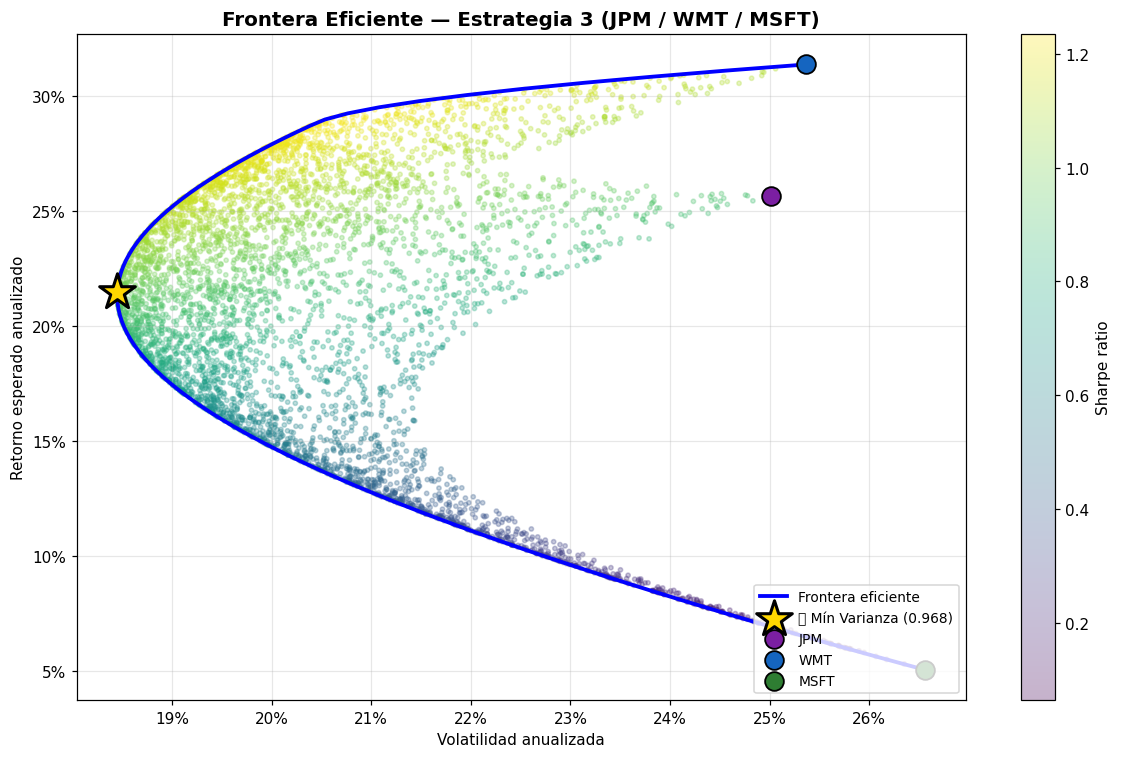

In [87]:
ret3  = returns_all[TICKERS_S3]
cov3  = ret3.cov() * 252
mu3   = ret3.mean() * 252
n3    = len(TICKERS_S3)

weights_s3 = optimize_minvar(cov3, n3)
ret_s3, std_s3 = portfolio_perf(weights_s3, mu3, cov3)

# Basket spot (ponderado por pesos) y parámetros para opciones
basket_spot = float(weights_s3 @ spots_s3)
vol_basket  = float(np.sqrt(weights_s3 @ cov3.values @ weights_s3))
div_basket  = float(sum(weights_s3[i] * S3_DIV[t] for i, t in enumerate(TICKERS_S3)))

print("=" * 60)
print("  PORTAFOLIO MÍNIMA VARIANZA — BASKET S3")
print("=" * 60)
for t, w in zip(TICKERS_S3, weights_s3):
    print(f"  {t}: {w*100:.2f}%")
print(f"\n  Retorno esperado anual:    {ret_s3*100:+.2f}%")
print(f"  Volatilidad anual:          {std_s3*100:.2f}%")
print(f"  Sharpe ratio:               {(ret_s3 - RISK_FREE)/std_s3:.3f}")
print(f"\n  Basket spot ponderado:     ${basket_spot:.4f}")
print(f"  Volatilidad del basket:     {vol_basket*100:.2f}%")
print(f"  Div yield ponderado:        {div_basket*100:.3f}%")

# ── Frontera eficiente S3 ─────────────────────────────────────────────────────
ef_ret3, ef_vol3 = efficient_frontier(mu3, cov3)
np.random.seed(SEED)
rw3 = np.random.dirichlet(np.ones(n3), 5000)
rr3 = rw3 @ mu3.values
rs3 = np.sqrt(np.einsum('ij,jk,ik->i', rw3, cov3.values, rw3))
r_mv3, s_mv3 = portfolio_perf(weights_s3, mu3, cov3)

fig, ax = plt.subplots(figsize=(11, 7))
sc = ax.scatter(rs3, rr3, c=(rr3 - RISK_FREE) / rs3, cmap='viridis', alpha=0.3, s=8)
plt.colorbar(sc, label='Sharpe ratio')
ax.plot(ef_vol3, ef_ret3, 'b-', lw=2.5, label='Frontera eficiente')
ax.scatter(s_mv3, r_mv3, marker='*', s=600, c='gold', edgecolors='k', lw=2, zorder=6,
           label=f"✅ Mín Varianza ({(r_mv3 - RISK_FREE)/s_mv3:.3f})")
colors_s3_pts = ['#7B1FA2', '#1565C0', '#2E7D32']
for i, (t, c) in enumerate(zip(TICKERS_S3, colors_s3_pts)):
    ax.scatter(np.sqrt(cov3.iloc[i, i]), mu3.iloc[i], marker='o', s=150,
               color=c, edgecolors='k', lw=1.2, label=t, zorder=4)
ax.set_xlabel('Volatilidad anualizada')
ax.set_ylabel('Retorno esperado anualizado')
ax.set_title('Frontera Eficiente — Estrategia 3 (JPM / WMT / MSFT)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
plt.tight_layout()
plt.show()

## S3-B. Pricing del Bull Call Spread sobre el Basket

In [88]:
# ── Strikes ───────────────────────────────────────────────────────────────────
K1_s3 = basket_spot                  # Long Call ATM
K2_s3 = basket_spot * (1 + S3_CAP)  # Short Call OTM (define el cap)

# ── Precios Black-Scholes (basket como subyacente único con vol del portafolio) ─
bs_call_atm_s3 = price_option('call', K1_s3, basket_spot, vol_basket, RISK_FREE, div_basket, T)
bs_call_otm_s3 = price_option('call', K2_s3, basket_spot, vol_basket, RISK_FREE, div_basket, T)

# ── Costo neto del spread y viabilidad ────────────────────────────────────────
spread_cost_abs  = bs_call_atm_s3 - bs_call_otm_s3    # $ por unidad de basket
spread_cost_pct  = spread_cost_abs / basket_spot        # fracción del basket
cost_spread_s3   = NOTIONAL * S3_PARTICIPATION * spread_cost_pct

pv_zcb3        = NOTIONAL * np.exp(-RISK_FREE * T)
option_budget3 = NOTIONAL - pv_zcb3
margen_s3      = option_budget3 - cost_spread_s3
viable_s3      = cost_spread_s3 <= option_budget3

print("=" * 70)
print("  ESTRATEGIA 3 — PRICING DEL BULL CALL SPREAD")
print("=" * 70)
print(f"\n  Basket spot (S0):             ${basket_spot:>10.4f}")
print(f"  K1 — Long  Call ATM:           ${K1_s3:>10.4f}  (= basket spot)")
print(f"  K2 — Short Call OTM (+{S3_CAP*100:.0f}%):   ${K2_s3:>10.4f}")
print(f"  Volatilidad del basket:        {vol_basket*100:>10.2f}%")
print(f"\n  BS precio Long  Call ATM:     ${bs_call_atm_s3:>10.4f}")
print(f"  BS precio Short Call OTM:     ${bs_call_otm_s3:>10.4f}")
print(f"  Costo neto del spread:        ${spread_cost_abs:>10.4f}  ({spread_cost_pct*100:.3f}% del basket)")
print(f"\n  ESTRUCTURA DE CAPITAL (${NOTIONAL:,} invertidos)")
print(f"    VP del ZCB @ {RISK_FREE*100:.2f}%:        ${pv_zcb3:>12,.2f}")
print(f"    Presupuesto opciones:       ${option_budget3:>12,.2f}")
print(f"    Costo spread (part 100%):   ${cost_spread_s3:>12,.2f}")
print(f"    Margen / Excedente:         ${margen_s3:>+12,.2f}")
print(f"\n  {'✅ VIABLE: spread dentro del presupuesto' if viable_s3 else '⚠️ NO VIABLE: reducir participación o ampliar cap'}")

  ESTRATEGIA 3 — PRICING DEL BULL CALL SPREAD

  Basket spot (S0):             $  274.1800
  K1 — Long  Call ATM:           $  274.1800  (= basket spot)
  K2 — Short Call OTM (+15%):   $  315.3070
  Volatilidad del basket:             18.45%

  BS precio Long  Call ATM:     $   10.8029
  BS precio Short Call OTM:     $    0.8751
  Costo neto del spread:        $    9.9278  (3.621% del basket)

  ESTRUCTURA DE CAPITAL ($100,000 invertidos)
    VP del ZCB @ 3.62%:        $   99,099.08
    Presupuesto opciones:       $      900.92
    Costo spread (part 100%):   $    3,620.91
    Margen / Excedente:         $   -2,719.99

  ⚠️ NO VIABLE: reducir participación o ampliar cap


## S3-C. Función de payoff — PPN Bull Call Spread

In [89]:
def ppn_basket_payoff(finals_s3, weights_arr, basket_spot_val, K1, K2,
                      notional, participation=1.0):
    """Payoff PPN con Bull Call Spread sobre basket mínima varianza.

    Payoff = notional + notional × part × max(0, min(R_basket, cap))
    Garantía: payoff ≥ notional siempre (spread ≥ 0 por construcción).
    """
    basket_ST   = finals_s3 @ weights_arr                         # valor basket al venc.
    call_long   = np.maximum(basket_ST - K1, 0)                   # long call ATM
    call_short  = np.maximum(basket_ST - K2, 0)                   # short call OTM (cap)
    spread_intr = (call_long - call_short) / basket_spot_val      # retorno del spread
    deriv_pf    = notional * participation * spread_intr
    payoff_tot  = notional + deriv_pf                             # siempre >= notional
    return payoff_tot, basket_ST, deriv_pf

cap_ret_s3 = (K2_s3 - K1_s3) / basket_spot   # = S3_CAP

print("✓ Función ppn_basket_payoff definida")
print(f"  Payoff = ${NOTIONAL:,} + ${NOTIONAL:,} × {S3_PARTICIPATION*100:.0f}% × max(0, min(R_basket, {S3_CAP*100:.0f}%))")
print(f"  Basket spot S0:   ${basket_spot:.4f}")
print(f"  K1 (ATM):         ${K1_s3:.4f}   K2 (OTM cap):  ${K2_s3:.4f}")
print(f"  Upside máximo:    ${NOTIONAL * S3_CAP:,.0f}  (+{S3_CAP*100:.0f}%)")

# Verificación
_test = (spots_s3 * 1.3).reshape(1, -1)
_pf, _, _ = ppn_basket_payoff(_test, weights_s3, basket_spot, K1_s3, K2_s3, NOTIONAL, S3_PARTICIPATION)
print(f"  Test +30% todos:  payoff = ${_pf[0]:,.0f}  (≤ ${NOTIONAL*(1+S3_CAP):,.0f} ✅)")
_pf_dn, _, _ = ppn_basket_payoff((spots_s3 * 0.8).reshape(1,-1), weights_s3, basket_spot, K1_s3, K2_s3, NOTIONAL, S3_PARTICIPATION)
print(f"  Test -20% todos:  payoff = ${_pf_dn[0]:,.0f}  (= ${NOTIONAL:,} capital ✅)")

✓ Función ppn_basket_payoff definida
  Payoff = $100,000 + $100,000 × 100% × max(0, min(R_basket, 15%))
  Basket spot S0:   $274.1800
  K1 (ATM):         $274.1800   K2 (OTM cap):  $315.3070
  Upside máximo:    $15,000  (+15%)
  Test +30% todos:  payoff = $115,000  (≤ $115,000 ✅)
  Test -20% todos:  payoff = $100,000  (= $100,000 capital ✅)


## S3-D. Monte Carlo — Pricing de la PPN

In [90]:
finals_s3 = simulate_gbm(spots_s3, vols_s3_hist, corr_s3, RISK_FREE, T, N_SIMS, SEED)

payoff3, basket_ST_sim, deriv_pf3 = ppn_basket_payoff(
    finals_s3, weights_s3, basket_spot, K1_s3, K2_s3, NOTIONAL, S3_PARTICIPATION
)

basket_ret_sim = (basket_ST_sim - basket_spot) / basket_spot
direct_mc_s3   = NOTIONAL * (1 + basket_ret_sim)

fair_value3 = np.exp(-RISK_FREE * T) * payoff3.mean()
exp_ret3    = payoff3.mean() / NOTIONAL - 1

print("=" * 70)
print("  PRICING PPN BULL CALL SPREAD (Monte Carlo)")
print("=" * 70)
print(f"\n  ✅ GARANTÍA VERIFICADA: payoff mínimo = ${payoff3.min():,.2f}")
print(f"\n  Fair value (VP payoffs):    ${fair_value3:>12,.2f}")
print(f"  Margen banco (@par):        ${NOTIONAL - fair_value3:>12,.2f}")
print(f"  Retorno esperado (3m):      {exp_ret3*100:>+8.2f}%  →  {exp_ret3/T*100:+.2f}% anual")
print(f"  Payoff promedio:            ${payoff3.mean():>12,.2f}")
print(f"  Payoff mínimo:              ${payoff3.min():>12,.2f}")
print(f"  Payoff percentil  5%:       ${np.percentile(payoff3,  5):>12,.2f}")
print(f"  Payoff percentil 50%:       ${np.percentile(payoff3, 50):>12,.2f}")
print(f"  Payoff percentil 95%:       ${np.percentile(payoff3, 95):>12,.2f}")
print(f"  Payoff máximo:              ${payoff3.max():>12,.2f}")
print(f"\n  Prob. ganancia (> capital): {(payoff3 > NOTIONAL).mean()*100:>8.1f}%")
print(f"  Prob. alcanzar cap ({S3_CAP*100:.0f}%):   {(basket_ret_sim >= S3_CAP - 1e-6).mean()*100:>8.1f}%")
print(f"  Retorno basket promedio:    {basket_ret_sim.mean()*100:>+8.2f}%")

  PRICING PPN BULL CALL SPREAD (Monte Carlo)

  ✅ GARANTÍA VERIFICADA: payoff mínimo = $100,000.00

  Fair value (VP payoffs):    $  103,000.58
  Margen banco (@par):        $   -3,000.58
  Retorno esperado (3m):         +3.94%  →  +15.75% anual
  Payoff promedio:            $  103,936.96
  Payoff mínimo:              $  100,000.00
  Payoff percentil  5%:       $  100,000.00
  Payoff percentil 50%:       $  100,427.78
  Payoff percentil 95%:       $  115,000.00
  Payoff máximo:              $  115,000.00

  Prob. ganancia (> capital):     51.7%
  Prob. alcanzar cap (15%):        8.3%
  Retorno basket promedio:       +0.91%


## S3-E. Visualización — Payoff y distribución

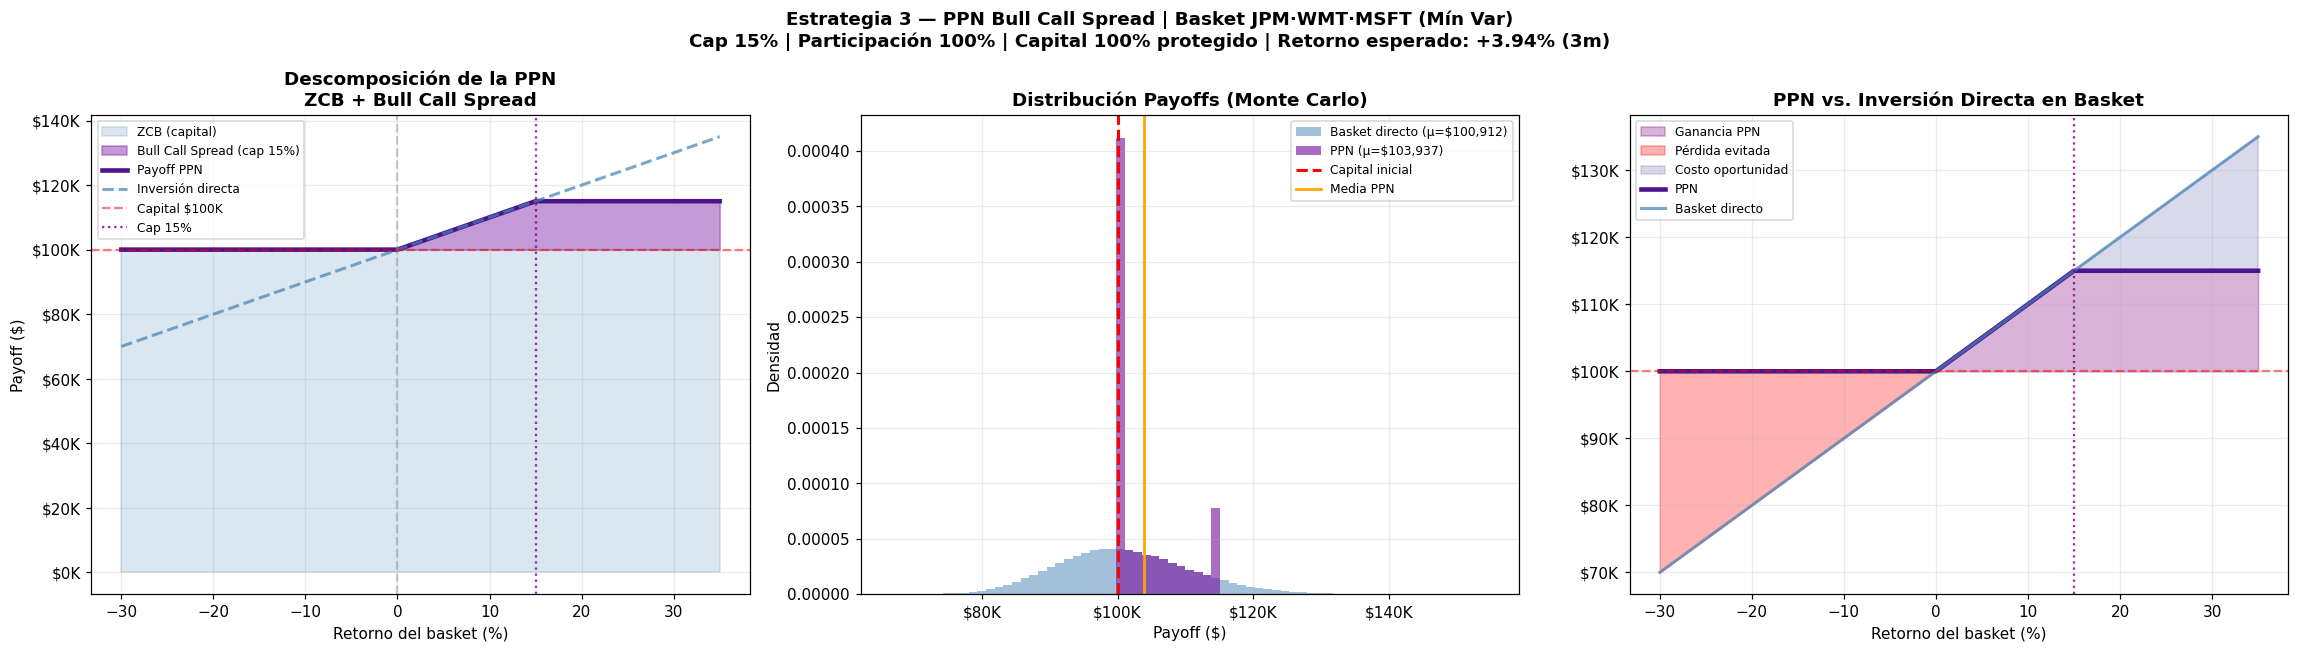

In [91]:
br_s3     = np.linspace(-0.30, 0.35, 500)
zcb_s3    = np.full(len(br_s3), NOTIONAL)
spread_s3 = np.minimum(np.maximum(br_s3, 0), S3_CAP) * NOTIONAL * S3_PARTICIPATION
total_s3  = zcb_s3 + spread_s3
direct_s3 = NOTIONAL * (1 + br_s3)

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# Panel 1: Descomposición ZCB + Bull Call Spread
ax = axes[0]
ax.fill_between(br_s3*100, 0, zcb_s3, alpha=0.20, color='steelblue', label='ZCB (capital)')
ax.fill_between(br_s3*100, zcb_s3, total_s3,
                alpha=0.45, color='#7B1FA2', label=f'Bull Call Spread (cap {S3_CAP*100:.0f}%)')
ax.plot(br_s3*100, total_s3,  lw=3,   color='#4A148C', label='Payoff PPN')
ax.plot(br_s3*100, direct_s3, lw=2,   color='steelblue', ls='--', alpha=0.7, label='Inversión directa')
ax.axhline(NOTIONAL, color='red', ls='--', alpha=0.5, lw=1.5, label=f'Capital ${NOTIONAL/1000:.0f}K')
ax.axvline(0,           color='gray',   ls='--', alpha=0.4)
ax.axvline(S3_CAP*100,  color='purple', ls=':',  alpha=0.8, label=f'Cap {S3_CAP*100:.0f}%')
ax.set_title('Descomposición de la PPN\nZCB + Bull Call Spread', fontweight='bold')
ax.set_xlabel('Retorno del basket (%)')
ax.set_ylabel('Payoff ($)')
ax.legend(fontsize=8, loc='upper left')
ax.grid(True, alpha=0.25)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# Panel 2: Distribución Monte Carlo (PPN vs Basket directo)
ax = axes[1]
lo3  = min(direct_mc_s3.min(), payoff3.min())
hi3  = max(direct_mc_s3.max(), payoff3.max())
bins3 = np.linspace(lo3, hi3, 70)
ax.hist(direct_mc_s3, bins=bins3, alpha=0.50, color='steelblue', density=True,
        label=f'Basket directo (μ=${direct_mc_s3.mean():,.0f})')
ax.hist(payoff3,      bins=bins3, alpha=0.65, color='#7B1FA2',   density=True,
        label=f'PPN (μ=${payoff3.mean():,.0f})')
ax.axvline(NOTIONAL,        color='red',    ls='--', lw=2,   label='Capital inicial')
ax.axvline(payoff3.mean(),  color='orange', ls='-',  lw=1.8, label=f'Media PPN')
ax.set_title('Distribución Payoffs (Monte Carlo)', fontweight='bold')
ax.set_xlabel('Payoff ($)')
ax.set_ylabel('Densidad')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# Panel 3: PPN vs Inversión directa en basket
ax = axes[2]
ax.fill_between(br_s3*100, NOTIONAL, total_s3,
                where=total_s3 > NOTIONAL, alpha=0.30, color='purple', label='Ganancia PPN')
ax.fill_between(br_s3*100, NOTIONAL, direct_s3,
                where=direct_s3 < NOTIONAL, alpha=0.30, color='red',   label='Pérdida evitada')
ax.fill_between(br_s3*100, total_s3, direct_s3,
                where=direct_s3 > total_s3, alpha=0.15, color='navy',  label='Costo oportunidad')
ax.plot(br_s3*100, total_s3,  lw=3, color='#4A148C',   label='PPN')
ax.plot(br_s3*100, direct_s3, lw=2, color='steelblue', alpha=0.7, label='Basket directo')
ax.axhline(NOTIONAL, color='red', ls='--', alpha=0.5)
ax.axvline(S3_CAP*100, color='purple', ls=':', alpha=0.8)
ax.set_title('PPN vs. Inversión Directa en Basket', fontweight='bold')
ax.set_xlabel('Retorno del basket (%)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

plt.suptitle(
    f'Estrategia 3 — PPN Bull Call Spread | Basket JPM·WMT·MSFT (Mín Var)\n'
    f'Cap {S3_CAP*100:.0f}% | Participación 100% | Capital 100% protegido | '
    f'Retorno esperado: {exp_ret3*100:+.2f}% (3m)',
    fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## S3-F. Distribución del payoff total y comparativa de retornos

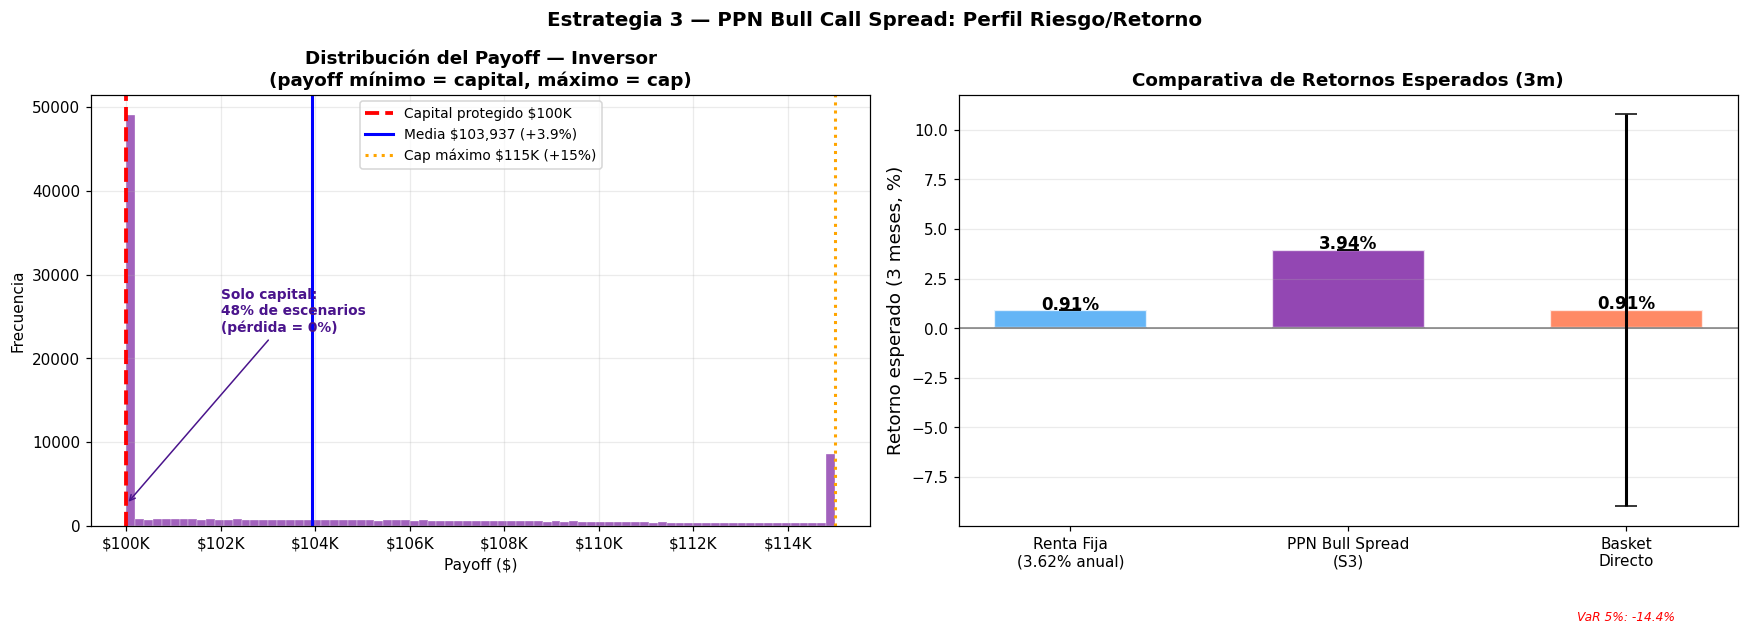

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Histograma del payoff del inversor
ax = axes[0]
ax.hist(payoff3, bins=80, color='#7B1FA2', alpha=0.7, edgecolor='white', linewidth=0.3)
ax.axvline(NOTIONAL,        color='red',    ls='--', lw=2.5,
           label=f'Capital protegido ${NOTIONAL/1000:.0f}K')
ax.axvline(payoff3.mean(),  color='blue',   ls='-',  lw=2,
           label=f'Media ${payoff3.mean():,.0f} ({exp_ret3*100:+.1f}%)')
ax.axvline(NOTIONAL*(1+S3_CAP), color='orange', ls=':', lw=2,
           label=f'Cap máximo ${NOTIONAL*(1+S3_CAP)/1000:.0f}K (+{S3_CAP*100:.0f}%)')
only_cap_pct3 = (payoff3 <= NOTIONAL + 1).mean() * 100
ax.annotate(f'Solo capital:\n{only_cap_pct3:.0f}% de escenarios\n(pérdida = 0%)',
            xy=(NOTIONAL, ax.get_ylim()[1]*0.05 if ax.get_ylim()[1] > 0 else 1000),
            xytext=(NOTIONAL * 1.02, ax.get_ylim()[1]*0.45 if ax.get_ylim()[1] > 0 else 5000),
            fontsize=9, color='#4A148C', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#4A148C'))
ax.set_title('Distribución del Payoff — Inversor\n(payoff mínimo = capital, máximo = cap)', fontweight='bold')
ax.set_xlabel('Payoff ($)')
ax.set_ylabel('Frecuencia')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# Panel 2: Comparativa de retornos esperados
ax2 = axes[1]
rf_return_s3    = RISK_FREE * T * 100
note_return_s3  = exp_ret3 * 100
direct_mean_s3  = float(basket_ret_sim.mean()) * 100
direct_std_s3   = float(basket_ret_sim.std()) * 100
direct_worst_s3 = float(np.percentile(basket_ret_sim, 5)) * 100

strat_labels_s3 = ['Renta Fija\n(3.62% anual)', 'PPN Bull Spread\n(S3)', 'Basket\nDirecto']
bar_vals_s3     = [rf_return_s3, note_return_s3, direct_mean_s3]
bcolors_s3      = ['#42A5F5', '#7B1FA2', '#FF7043']

bars3 = ax2.bar(strat_labels_s3, bar_vals_s3, color=bcolors_s3, alpha=0.82,
                edgecolor='white', linewidth=1.5, width=0.55)
ax2.errorbar(strat_labels_s3, bar_vals_s3, yerr=[0, 0, direct_std_s3],
             fmt='none', color='black', capsize=7, linewidth=2)
for bar, val in zip(bars3, bar_vals_s3):
    ax2.text(bar.get_x() + bar.get_width()/2, max(val, 0) + 0.05,
             f'{val:.2f}%', ha='center', fontweight='bold', fontsize=11)
ax2.text(2, direct_worst_s3 - 0.35, f'VaR 5%: {direct_worst_s3:.1f}%',
         ha='center', fontsize=8, color='red', style='italic')
ax2.axhline(0, color='black', lw=1, alpha=0.5)
ax2.set_ylabel('Retorno esperado (3 meses, %)', fontsize=12)
ax2.set_title('Comparativa de Retornos Esperados (3m)', fontweight='bold')
ax2.grid(True, alpha=0.25, axis='y')

plt.suptitle('Estrategia 3 — PPN Bull Call Spread: Perfil Riesgo/Retorno',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## S3-G. Tabla de escenarios numéricos

In [93]:
print("\n" + "=" * 105)
print("  ANÁLISIS DE ESCENARIOS — PPN BULL CALL SPREAD (JPM · WMT · MSFT)")
print("=" * 105)

scenarios_s3 = [
    ( 0.20,  0.20,  0.20, "Rally generalizado +20%  ← CAP ACTIVO"),
    ( 0.15,  0.15,  0.15, "Alza +15% — exactamente en el cap"),
    ( 0.10,  0.10,  0.10, "Alza moderada +10%"),
    ( 0.20,  0.05,  0.15, "JPM lidera / WMT rezagado"),
    ( 0.05,  0.20,  0.10, "WMT lidera"),
    ( 0.10,  0.10,  0.20, "MSFT acelera / JPM y WMT moderados"),
    ( 0.05,  0.05,  0.05, "Leve alza +5%"),
    ( 0.00,  0.00,  0.00, "Flat (sin movimiento)"),
    (-0.05, -0.05, -0.05, "Leve corrección -5%  ← capital protegido"),
    (-0.10, -0.15, -0.10, "Corrección moderada"),
    (-0.20, -0.20, -0.20, "Corrección severa -20%"),
    ( 0.30,  0.25,  0.35, "Rally extremo (cap activo al 15%)"),
]

rows_s3 = []
for r_jpm, r_wmt, r_msft, desc in scenarios_s3:
    rets_sc   = np.array([r_jpm, r_wmt, r_msft])
    finals_sc = (spots_s3 * (1 + rets_sc)).reshape(1, -1)
    pf_sc, bask_sc, der_sc = ppn_basket_payoff(
        finals_sc, weights_s3, basket_spot, K1_s3, K2_s3, NOTIONAL, S3_PARTICIPATION
    )
    bask_ret_sc = (float(bask_sc[0]) - basket_spot) / basket_spot
    cap_hit     = bask_ret_sc >= S3_CAP - 1e-4
    ganancia    = float(pf_sc[0]) > NOTIONAL + 0.01
    resultado   = (f'🔒 Cap ({S3_CAP*100:.0f}%)' if cap_hit
                   else ('✅ Ganancia' if ganancia else '⬜ Solo capital'))
    rows_s3.append({
        'Escenario':      desc,
        'JPM':            f'{r_jpm*100:+.0f}%',
        'WMT':            f'{r_wmt*100:+.0f}%',
        'MSFT':           f'{r_msft*100:+.0f}%',
        'Basket ret':     f'{bask_ret_sc*100:+.2f}%',
        'Spread ($)':     f'${der_sc[0]:>8,.0f}',
        'Payoff total':   f'${pf_sc[0]:>10,.0f}',
        'Rend. 3m':       f'{(float(pf_sc[0])/NOTIONAL - 1)*100:+.2f}%',
        'Resultado':      resultado,
    })

df_s3 = pd.DataFrame(rows_s3)
print(df_s3.to_string(index=False))
df_s3


  ANÁLISIS DE ESCENARIOS — PPN BULL CALL SPREAD (JPM · WMT · MSFT)
                               Escenario  JPM  WMT MSFT Basket ret Spread ($) Payoff total Rend. 3m      Resultado
   Rally generalizado +20%  ← CAP ACTIVO +20% +20% +20%    +20.00%  $  15,000  $   115,000  +15.00%    🔒 Cap (15%)
       Alza +15% — exactamente en el cap +15% +15% +15%    +15.00%  $  15,000  $   115,000  +15.00%    🔒 Cap (15%)
                      Alza moderada +10% +10% +10% +10%    +10.00%  $  10,000  $   110,000  +10.00%     ✅ Ganancia
               JPM lidera / WMT rezagado +20%  +5% +15%    +14.90%  $  14,896  $   114,896  +14.90%     ✅ Ganancia
                              WMT lidera  +5% +20% +10%    +10.10%  $  10,104  $   110,104  +10.10%     ✅ Ganancia
      MSFT acelera / JPM y WMT moderados +10% +10% +20%    +14.79%  $  14,786  $   114,786  +14.79%     ✅ Ganancia
                           Leve alza +5%  +5%  +5%  +5%     +5.00%  $   5,000  $   105,000   +5.00%     ✅ Ganancia
            

,Escenario,JPM,WMT,MSFT,Basket ret,Spread ($),Payoff total,Rend. 3m,Resultado
0,Rally generalizado +20% ← CAP ACTIVO,+20%,+20%,+20%,+20.00%,"$ 15,000","$ 115,000",+15.00%,🔒 Cap (15%)
1,Alza +15% — exactamente en el cap,+15%,+15%,+15%,+15.00%,"$ 15,000","$ 115,000",+15.00%,🔒 Cap (15%)
2,Alza moderada +10%,+10%,+10%,+10%,+10.00%,"$ 10,000","$ 110,000",+10.00%,✅ Ganancia
3,JPM lidera / WMT rezagado,+20%,+5%,+15%,+14.90%,"$ 14,896","$ 114,896",+14.90%,✅ Ganancia
4,WMT lidera,+5%,+20%,+10%,+10.10%,"$ 10,104","$ 110,104",+10.10%,✅ Ganancia
5,MSFT acelera / JPM y WMT moderados,+10%,+10%,+20%,+14.79%,"$ 14,786","$ 114,786",+14.79%,✅ Ganancia
6,Leve alza +5%,+5%,+5%,+5%,+5.00%,"$ 5,000","$ 105,000",+5.00%,✅ Ganancia
7,Flat (sin movimiento),+0%,+0%,+0%,+0.00%,$ 0,"$ 100,000",+0.00%,⬜ Solo capital
8,Leve corrección -5% ← capital protegido,-5%,-5%,-5%,-5.00%,$ 0,"$ 100,000",+0.00%,⬜ Solo capital
9,Corrección moderada,-10%,-15%,-10%,-10.90%,$ 0,"$ 100,000",+0.00%,⬜ Solo capital


---
# 📋 Resumen Comparativo — Las 3 Estrategias

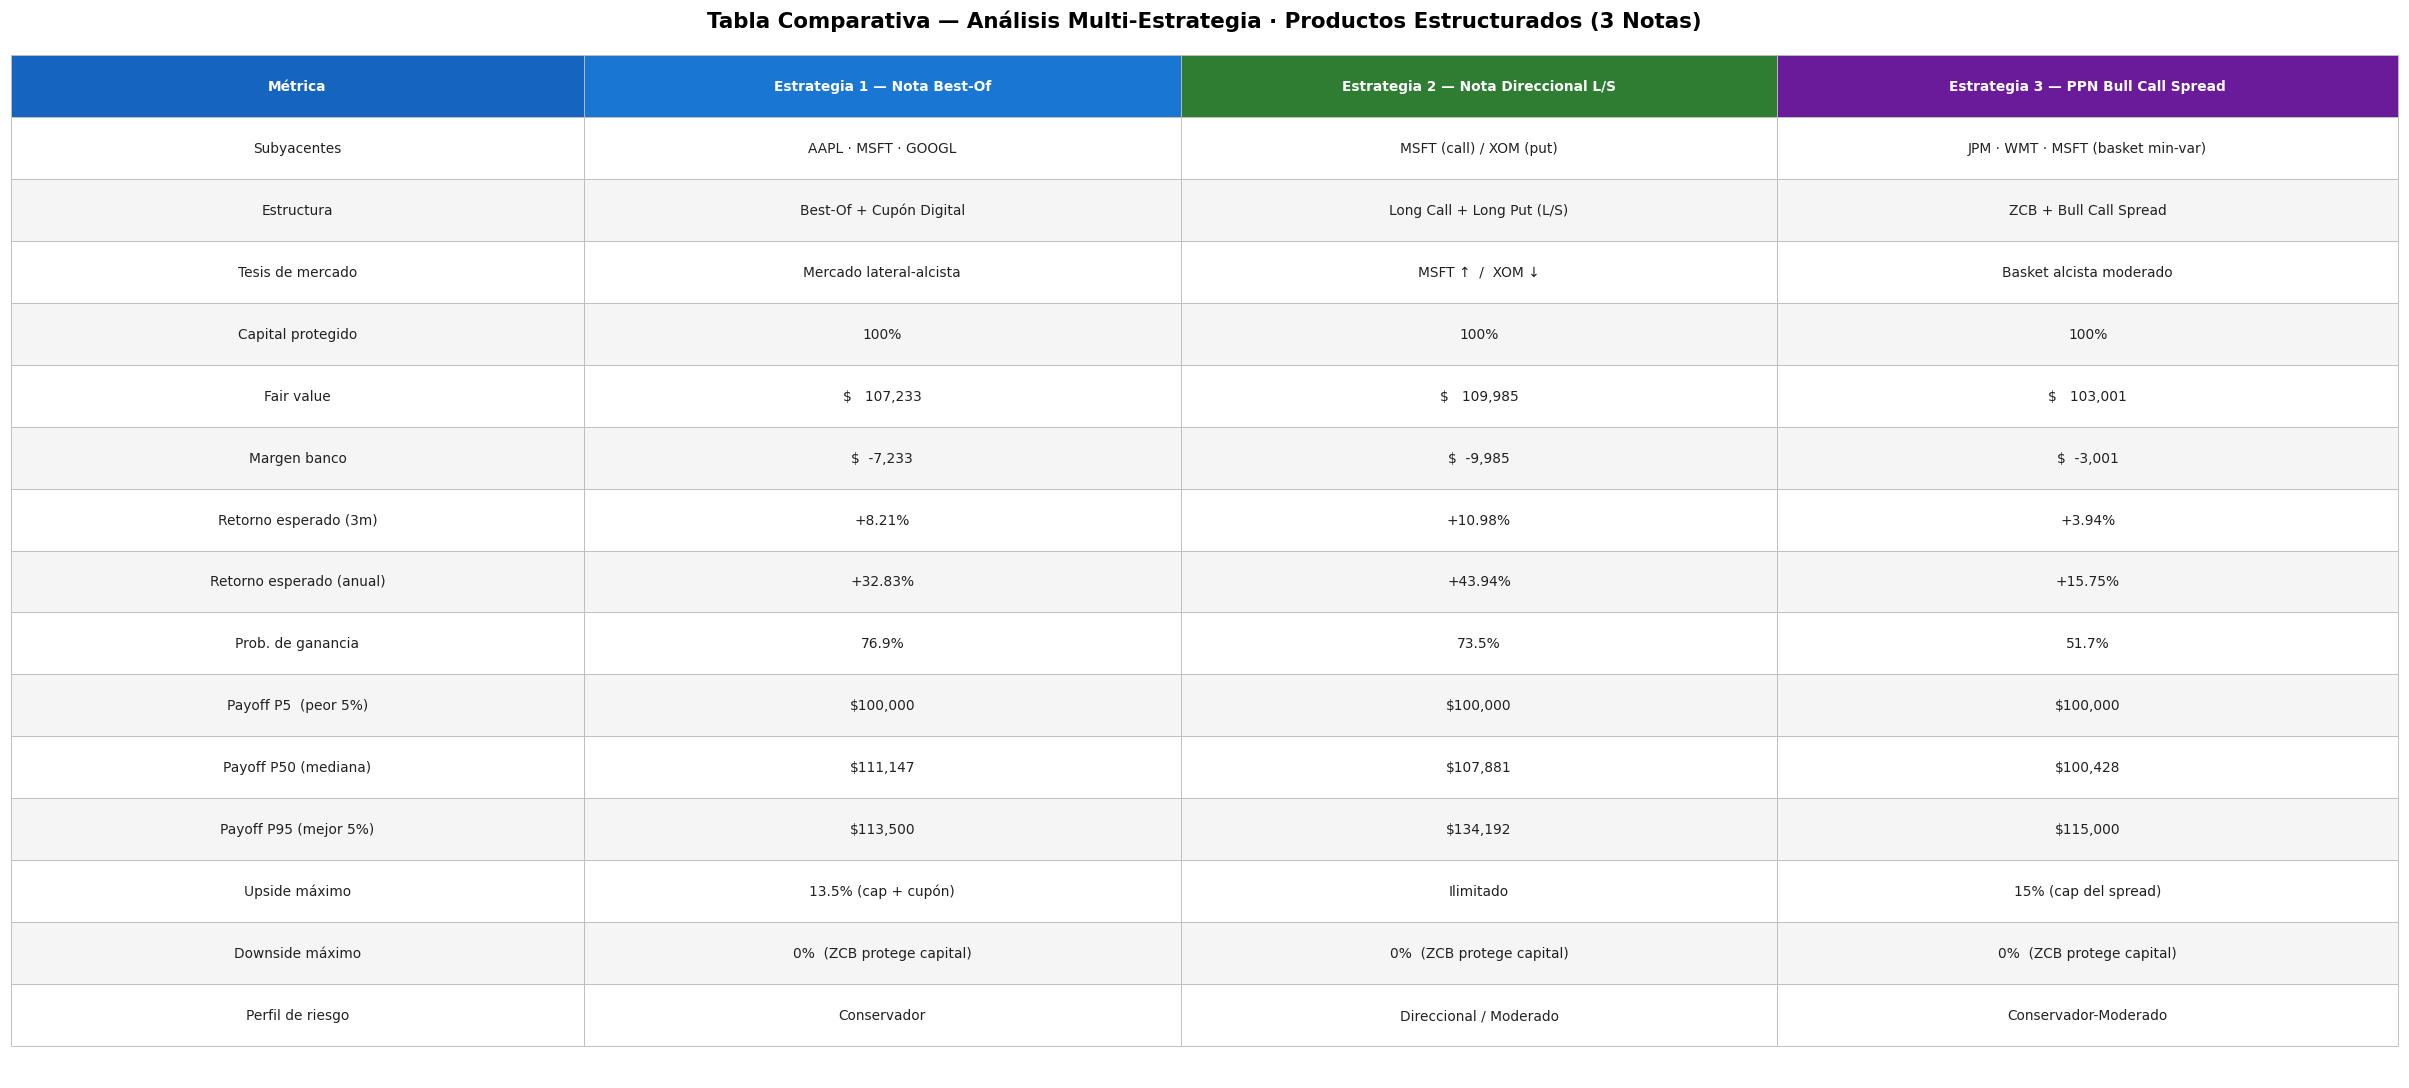

In [94]:
# ── Tabla visual comparativa — las 3 estrategias ────────────────────────────
fig, ax = plt.subplots(figsize=(22, 10))
ax.axis('off')

metrics = [
    ['Métrica',
     'Estrategia 1 — Nota Best-Of',
     'Estrategia 2 — Nota Direccional L/S',
     'Estrategia 3 — PPN Bull Call Spread'],
    ['Subyacentes',
     'AAPL · MSFT · GOOGL',
     'MSFT (call) / XOM (put)',
     'JPM · WMT · MSFT (basket min-var)'],
    ['Estructura',
     'Best-Of + Cupón Digital',
     'Long Call + Long Put (L/S)',
     'ZCB + Bull Call Spread'],
    ['Tesis de mercado',
     'Mercado lateral-alcista',
     'MSFT ↑  /  XOM ↓',
     'Basket alcista moderado'],
    ['Capital protegido',
     '100%', '100%', '100%'],
    ['Fair value',
     f'${fair_value1:>10,.0f}',
     f'${fair_value2:>10,.0f}',
     f'${fair_value3:>10,.0f}'],
    ['Margen banco',
     f'${NOTIONAL - fair_value1:>8,.0f}',
     f'${NOTIONAL - fair_value2:>8,.0f}',
     f'${NOTIONAL - fair_value3:>8,.0f}'],
    ['Retorno esperado (3m)',
     f'{exp_ret1*100:+.2f}%',
     f'{exp_ret2*100:+.2f}%',
     f'{exp_ret3*100:+.2f}%'],
    ['Retorno esperado (anual)',
     f'{exp_ret1/T*100:+.2f}%',
     f'{exp_ret2/T*100:+.2f}%',
     f'{exp_ret3/T*100:+.2f}%'],
    ['Prob. de ganancia',
     f'{(payoff1>NOTIONAL).mean()*100:.1f}%',
     f'{(payoff2>NOTIONAL).mean()*100:.1f}%',
     f'{(payoff3>NOTIONAL).mean()*100:.1f}%'],
    ['Payoff P5  (peor 5%)',
     f'${np.percentile(payoff1,  5):,.0f}',
     f'${np.percentile(payoff2,  5):,.0f}',
     f'${np.percentile(payoff3,  5):,.0f}'],
    ['Payoff P50 (mediana)',
     f'${np.percentile(payoff1, 50):,.0f}',
     f'${np.percentile(payoff2, 50):,.0f}',
     f'${np.percentile(payoff3, 50):,.0f}'],
    ['Payoff P95 (mejor 5%)',
     f'${np.percentile(payoff1, 95):,.0f}',
     f'${np.percentile(payoff2, 95):,.0f}',
     f'${np.percentile(payoff3, 95):,.0f}'],
    ['Upside máximo',
     f'{(S1_CAP+S1_COUPON)*100:.1f}% (cap + cupón)',
     'Ilimitado',
     f'{S3_CAP*100:.0f}% (cap del spread)'],
    ['Downside máximo',
     '0%  (ZCB protege capital)',
     '0%  (ZCB protege capital)',
     '0%  (ZCB protege capital)'],
    ['Perfil de riesgo',
     'Conservador',
     'Direccional / Moderado',
     'Conservador-Moderado'],
]

col_widths = [0.24, 0.25, 0.25, 0.26]
col_starts = [0.0,  0.24, 0.49, 0.74]
row_height = 1 / (len(metrics) + 0.5)

header_clr = '#1565C0'
s1_clr     = '#1976D2'
s2_clr     = '#2E7D32'
s3_clr     = '#6A1B9A'
even_clr   = '#F5F5F5'
odd_clr    = '#FFFFFF'

for r, row in enumerate(metrics):
    for c, (txt, cw, cx) in enumerate(zip(row, col_widths, col_starts)):
        if r == 0:
            bg = header_clr if c == 0 else {1: s1_clr, 2: s2_clr, 3: s3_clr}[c]
            fc, fw = 'white', 'bold'
        else:
            bg = even_clr if r % 2 == 0 else odd_clr
            fc, fw = '#212121', 'normal'

        y_bot = 1 - (r + 1) * row_height
        rect = plt.Rectangle((cx, y_bot), cw, row_height,
                              facecolor=bg, edgecolor='#BDBDBD', linewidth=0.6,
                              transform=ax.transAxes, clip_on=False)
        ax.add_patch(rect)
        ax.text(cx + cw / 2, y_bot + row_height / 2, txt,
                ha='center', va='center', fontsize=9,
                color=fc, fontweight=fw, transform=ax.transAxes)

ax.set_title(
    'Tabla Comparativa — Análisis Multi-Estrategia · Productos Estructurados (3 Notas)',
    fontsize=14, fontweight='bold', pad=18
)
plt.tight_layout()
plt.show()